# **Capa Silver - 2**

In [1]:
# Conexión con drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PALETA = {
    "negro": "#2E2929", "blanco": "#F1F1F1", "amarillo": "#FFD400", "naranja": "#FF8120",
    "violeta": "#A35BCF", "azul": "#1DB8D3", "verde": "#14C48A", "rosa": "#EFA6C2",
}
PRINCIPAL = PALETA["verde"]
SECUNDARIO = PALETA["azul"]
ALERTA = PALETA["naranja"]
ATENUADO = PALETA["negro"]
GRID = PALETA["negro"]

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 20.4 MB/s eta 0:00:00


In [4]:
# Librerias
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
# kmeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import optuna
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_gamma_deviance, r2_score, mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [5]:
def db_to_dataframe(db_path, table_name=None):
    conn = sqlite3.connect(db_path)
    try:
        if table_name is None:
            table_name = pd.read_sql(
                "SELECT name FROM sqlite_master WHERE type='table' LIMIT 1;",
                conn
            ).iloc[0, 0]

        df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
        return df
    finally:
        conn.close()

In [6]:
df_abt_crean = db_to_dataframe('/content/drive/MyDrive/df_abt_crean_con_clusters.db')

In [7]:
panel_invesbot = db_to_dataframe('/content/drive/MyDrive/data/panel_invesbot_mensual.db', 'panel_invesbot_mensual')
panel_inv_cdt = db_to_dataframe('/content/drive/MyDrive/data/panel_inv_virtual_cdt_mensual.db', 'panel_inv_virtual_cdt_mensual')

for panel in [panel_invesbot, panel_inv_cdt]:
    panel["año_mes"] = pd.PeriodIndex(pd.to_datetime(panel["año_mes"]), freq="M")

panel_inv_virtual = panel_inv_cdt[panel_inv_cdt["producto"].str.contains("VIRTUAL", case=False, na=False)].copy()
panel_cdt = panel_inv_cdt[panel_inv_cdt["producto"] == "CDT"].copy()

scores_propension_adopcion = pd.read_csv("/content/drive/MyDrive/data/scores_propension_adopcion.csv")

In [8]:
df_abt_crean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860223 entries, 0 to 860222
Data columns (total 88 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   numero_id                                     860223 non-null  object 
 1   grupo_edad                                    860223 non-null  object 
 2   desc_genero                                   860223 non-null  object 
 3   desc_segmento                                 860223 non-null  object 
 4   desc_tipo_de_vivienda                         860223 non-null  object 
 5   ingresos_mensuales                            860223 non-null  float64
 6   total_egresos_mensuales                       860223 non-null  float64
 7   total_activos                                 860223 non-null  float64
 8   total_pasivos                                 860223 non-null  float64
 9   total_patrimonio                              86

# Aprendizaje Supervisado

**Objetivo:** Construir un modelo para estimar el potencial de inversión de los clientes en base a supuestos.

### Limitaciones conocidas de la fuente de datos

El panel historico disponible cubre unicamente ~13 meses, lo que impide validar el modelo fuera de tiempo (out-of-time) o estudiar en profundidad como cambia el comportamiento de un cliente a lo largo de varios anios. Como consecuencia directa:

1. El target de monto invertido se aproxima con dos regimenes distintos (ventana de 6 meses vs. mediana historica completa) en vez de medirse de forma exacta a 12 meses.
2. Los grupos de "adopcion reciente verificada" son chicos en CDT (2,246 clientes) e invesbot (1,165 clientes) frente a inversion virtual (11,033), asi que sus estimaciones son las menos firmes de los tres productos.
3. El modelo de monto se entrena solo sobre quienes ya invierten y se aplica por parecido (look-alike) al resto de la base, sin poder contrastarlo contra un grupo de no-inversionistas que despues si haya invertido.

Estas tres limitaciones son estructurales a la fuente de datos.

### Matriz de correlación con todas las variables continuas candidatas

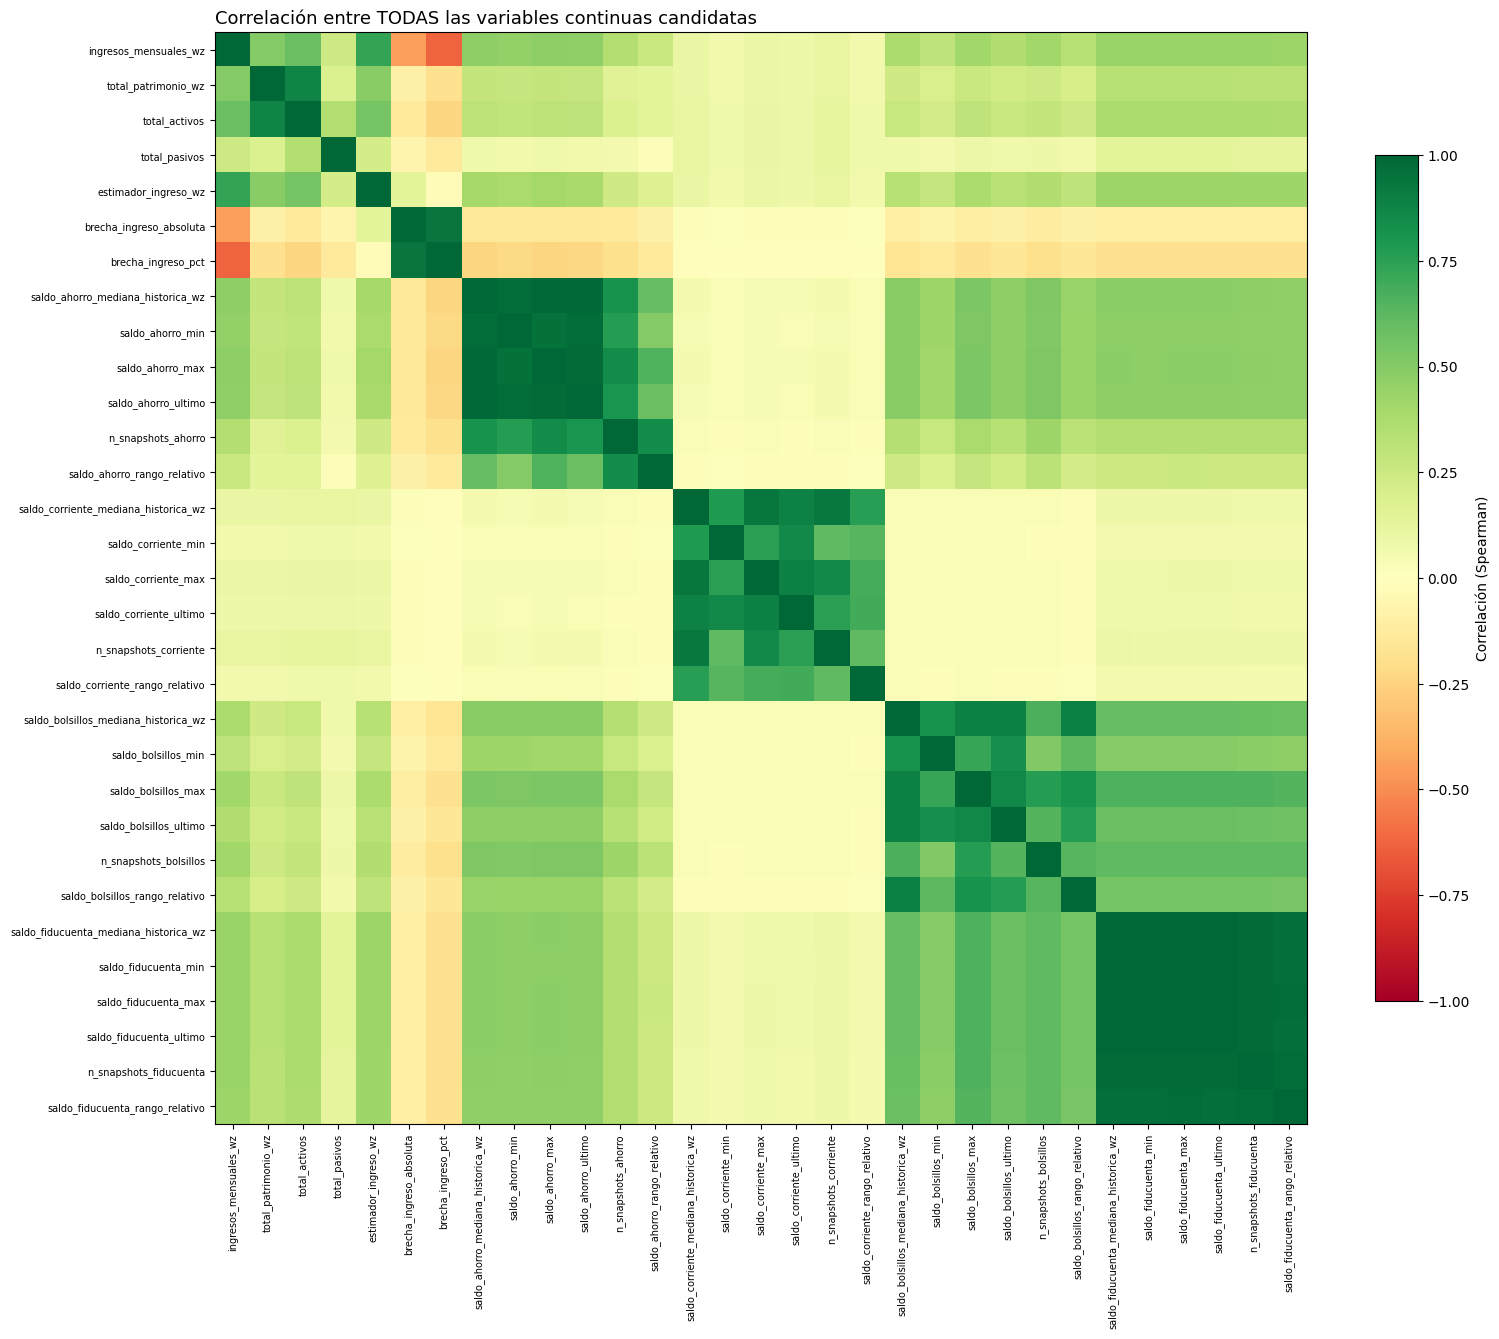

In [9]:
cols_continuas_todas = [
    "ingresos_mensuales_wz", "total_patrimonio_wz", "total_activos", "total_pasivos",
    "estimador_ingreso_wz", "brecha_ingreso_absoluta", "brecha_ingreso_pct",
    "saldo_ahorro_mediana_historica_wz", "saldo_ahorro_min", "saldo_ahorro_max", "saldo_ahorro_ultimo", "n_snapshots_ahorro", "saldo_ahorro_rango_relativo",
    "saldo_corriente_mediana_historica_wz", "saldo_corriente_min", "saldo_corriente_max", "saldo_corriente_ultimo", "n_snapshots_corriente", "saldo_corriente_rango_relativo",
    "saldo_bolsillos_mediana_historica_wz", "saldo_bolsillos_min", "saldo_bolsillos_max", "saldo_bolsillos_ultimo", "n_snapshots_bolsillos", "saldo_bolsillos_rango_relativo",
    "saldo_fiducuenta_mediana_historica_wz", "saldo_fiducuenta_min", "saldo_fiducuenta_max", "saldo_fiducuenta_ultimo", "n_snapshots_fiducuenta", "saldo_fiducuenta_rango_relativo",
]

corr_matrix = df_abt_crean[cols_continuas_todas].corr(method="spearman")

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_continuas_todas))); ax.set_xticklabels(cols_continuas_todas, rotation=90, ha="center", fontsize=7)
ax.set_yticks(range(len(cols_continuas_todas))); ax.set_yticklabels(cols_continuas_todas, fontsize=7)
plt.colorbar(im, label="Correlación (Spearman)", shrink=0.7)
ax.set_title("Correlación entre TODAS las variables continuas candidatas", fontsize=13, loc="left")
plt.tight_layout(); plt.show()


In [10]:
# tabla de pares con correlación alta, para no depender solo de leer el mapa de calor
pares_altos = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "var_1", "level_1": "var_2", 0: "correlacion"})
)
pares_altos = pares_altos[pares_altos["correlacion"].abs() >= 0.8].sort_values("correlacion", ascending=False)
print(pares_altos.to_string(index=False))

                                var_1                           var_2  correlacion
saldo_fiducuenta_mediana_historica_wz         saldo_fiducuenta_ultimo     0.998064
saldo_fiducuenta_mediana_historica_wz            saldo_fiducuenta_max     0.998028
                 saldo_fiducuenta_min         saldo_fiducuenta_ultimo     0.998004
saldo_fiducuenta_mediana_historica_wz            saldo_fiducuenta_min     0.997805
                 saldo_fiducuenta_max         saldo_fiducuenta_ultimo     0.997061
                 saldo_fiducuenta_min            saldo_fiducuenta_max     0.995195
    saldo_ahorro_mediana_historica_wz                saldo_ahorro_max     0.990740
    saldo_ahorro_mediana_historica_wz             saldo_ahorro_ultimo     0.985278
                 saldo_fiducuenta_max          n_snapshots_fiducuenta     0.982120
              saldo_fiducuenta_ultimo          n_snapshots_fiducuenta     0.981181
saldo_fiducuenta_mediana_historica_wz          n_snapshots_fiducuenta     0.981100
    

**Qué revela esta tabla de correlaciones:**

Al mirar los pares de variables con mayor correlación, aparece un patrón muy claro: para cada producto financiero (fiducuenta, ahorro, cuenta corriente y bolsillos), las distintas formas de resumir el saldo de un cliente a lo largo del tiempo —su mediana histórica, su valor máximo, su valor mínimo, su saldo más reciente, y hasta cuántos meses aparece registrado ese producto— están midiendo, en la práctica, casi lo mismo. En fiducuenta, por ejemplo, estas variables coinciden entre sí con una correlación de hasta 0.998, es decir, prácticamente son la misma información repetida bajo distintos nombres.

Esto tiene una explicación sencilla: el saldo de la mayoría de los clientes en un producto determinado no cambia demasiado de un mes a otro. Si alguien mantiene un comportamiento relativamente estable en su fiducuenta o su cuenta de ahorros, da lo mismo mirar su promedio, su máximo o su último valor registrado — el número que arrojan es casi idéntico en los tres casos.

Este patrón se repite, con distinta intensidad, en los cuatro productos revisados. Es más marcado en **fiducuenta** (correlaciones cercanas a 0.998, prácticamente sin diferencia entre las variables) y algo menos marcado en **bolsillos** (correlaciones alrededor de 0.81-0.90), lo que sugiere que el comportamiento en bolsillos es un poco más variable mes a mes que en los otros productos — tiene sentido, ya que es un producto que el cliente suele mover con más frecuencia.

También aparecen dos coincidencias fuera de este patrón por producto: la brecha de ingreso medida en pesos y la misma brecha medida en porcentaje están altamente relacionadas entre sí (0.94), lo cual es esperable porque describen la misma diferencia solo que expresada de dos formas distintas; y el patrimonio total del cliente está fuertemente relacionado con el total de sus activos (0.88), lo que indica que, para la mayoría de los clientes, sus deudas no varían tanto como para separar mucho estos dos conceptos.

**La implicación práctica es directa:** no tiene sentido mantener todas estas variables por separado al construir un modelo, porque no están aportando información nueva entre sí — son, en el fondo, la misma señal contada varias veces. Quedarse con una sola medida representativa por producto (como ya se ha hecho en este estudio usando la mediana) captura casi toda la información disponible, sin inflar artificialmente el peso de un producto en el modelo solo por tener más variables asociadas a él.

### Redundancia binaria vs. continua

In [11]:
for saldo, flag in [
    ("saldo_ahorro_mediana_historica_wz", "tiene_ahorro"),
    ("saldo_corriente_mediana_historica_wz", "tiene_corriente"),
    ("saldo_bolsillos_mediana_historica_wz", "tiene_bolsillos"),
    ("saldo_fiducuenta_mediana_historica_wz", "tiene_fiducuenta"),
]:
    corr = df_abt_crean[saldo].corr(df_abt_crean[flag], method="spearman")
    print(f"{saldo} vs {flag}: {corr:.3f}")

corr_sobregiro = df_abt_crean["tuvo_sobregiro"].corr(df_abt_crean["tuvo_sobregiro_atipico"], method="spearman")
print(f"tuvo_sobregiro vs tuvo_sobregiro_atipico: {corr_sobregiro:.3f}")


saldo_ahorro_mediana_historica_wz vs tiene_ahorro: 0.860
saldo_corriente_mediana_historica_wz vs tiene_corriente: 0.929
saldo_bolsillos_mediana_historica_wz vs tiene_bolsillos: 0.684
saldo_fiducuenta_mediana_historica_wz vs tiene_fiducuenta: 0.991
tuvo_sobregiro vs tuvo_sobregiro_atipico: 0.053


### Qué revela la comparación entre saldo y tenencia del producto

Aquí se compara, para cada producto, si el saldo del cliente y la simple bandera de "sí tiene / no tiene" ese producto están diciendo básicamente lo mismo, o si aportan información distinta.

En **fiducuenta** (0.991) y **cuenta corriente** (0.929) la relación es prácticamente total: si un cliente tiene el producto, casi con seguridad tiene un saldo asociado, y si no lo tiene, el saldo es cero. En estos dos casos, saber si el cliente "tiene" el producto no agrega casi nada que el saldo no esté diciendo ya — son, en la práctica, la misma señal contada dos veces.

En **ahorro** (0.860) la relación sigue siendo alta, pero ya no tan cerrada como en los dos casos anteriores. Esto tiene sentido: la cuenta de ahorros es un producto casi universal —la tiene casi cualquier cliente del banco—, así que tener la cuenta no dice tanto sobre cuánto dinero maneja, hay clientes con la cuenta activa pero con saldos muy bajos o muy variables.

El caso más distinto es **bolsillos** (0.684): aquí la bandera de tenencia y el saldo dejan de ser intercambiables. Que un cliente tenga bolsillos activado no permite anticipar con la misma certeza cuánto dinero guarda ahí — es un producto que la gente usa de forma más variada, algunos lo usan activamente para guardar sumas importantes, otros apenas lo tienen abierto con poco movimiento. En este caso, la tenencia y el saldo cuentan historias distintas y conviene conservar ambas señales.

Por último, **tuvo_sobregiro** y **tuvo_sobregiro_atipico** (0.053) resultan prácticamente independientes entre sí, a pesar de que sus nombres suenan parecidos. Esto indica que no están midiendo la misma situación: haber tenido un sobregiro común no predice haber tenido uno atípico, así que ambas variables capturan comportamientos distintos y ninguna sobra frente a la otra.

**La implicación práctica:** siguiendo el mismo criterio ya usado en este estudio (considerar redundante un par cuando su correlación supera 0.9), en fiducuenta y cuenta corriente basta con conservar el saldo y se puede prescindir de la bandera de tenencia sin perder información. En ahorro, bolsillos y en el par de sobregiro, en cambio, cada variable aporta algo distinto y vale la pena conservarlas todas.

### Universo de entrenamiento y variable objetivo

**Por qué CDT sí entra aquí, aunque no cuenta como "adopción digital" en el modelo de propensión:** los dos modelos responden preguntas distintas. Propensión mide si un cliente va a adoptar la nueva app —un producto digital—, así que CDT (inversión tradicional, no digital) queda fuera de esa definición a propósito. Este modelo mide algo distinto: cuánto invierte alguien con este perfil financiero. Para esa pregunta, un tenedor de CDT sí demuestra capacidad e intención real de invertir, aunque no haya sido por canal digital, y es información legítima para calibrar el monto — aunque no lo sería para medir adopción de la app.

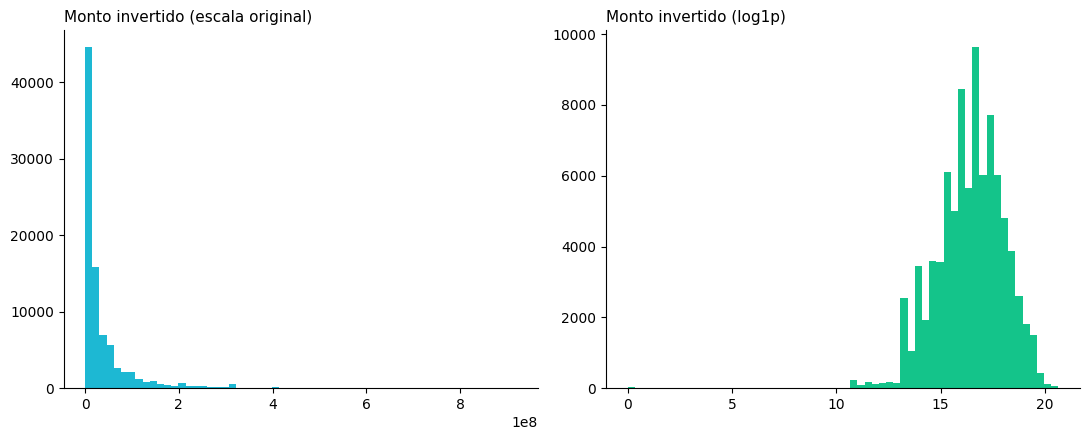

Inversionistas: 87,032 (10.12% de la base)


In [12]:
inversionistas = df_abt_crean[
    (df_abt_crean["tiene_cdt"] == 1) | (df_abt_crean["tiene_inv_virtual"] == 1) | (df_abt_crean["tiene_invesbot"] == 1)
].copy()

inversionistas["monto_invertido"] = (
    inversionistas["saldo_cdt_mediana_historica_wz"] +
    inversionistas["saldo_inversion_virtual_mediana_historica_wz"] +
    inversionistas["saldo_invesbot_mediana_historica_wz"]
)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].hist(inversionistas["monto_invertido"], bins=60, color=SECUNDARIO)
ax[0].set_title("Monto invertido (escala original)", fontsize=11, loc="left")
ax[1].hist(np.log1p(inversionistas["monto_invertido"]), bins=60, color=PRINCIPAL)
ax[1].set_title("Monto invertido (log1p)", fontsize=11, loc="left")
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(f"Inversionistas: {len(inversionistas):,} ({len(inversionistas)/len(df_abt_crean)*100:.2f}% de la base)")

In [13]:
def construir_target_producto(panel, nombre_producto, col_saldo_completo_abt, ventana_meses=6, minimo_snapshots_ventana=3):
    fecha_adopcion = panel.groupby("numero_id")["año_mes"].min().rename("fecha_adopcion")
    mes_inicio_panel = panel["año_mes"].min()
    mes_fin_panel = panel["año_mes"].max()

    es_preexistente = (fecha_adopcion == mes_inicio_panel).rename("preexistente")
    meses_disponibles = (mes_fin_panel - fecha_adopcion).apply(lambda p: p.n).rename("meses_disponibles")

    con_fecha = panel.merge(fecha_adopcion.reset_index(), on="numero_id")
    con_fecha["mes_relativo"] = (con_fecha["año_mes"] - con_fecha["fecha_adopcion"]).apply(lambda p: p.n)
    ventana = con_fecha[(con_fecha["mes_relativo"] >= 0) & (con_fecha["mes_relativo"] < ventana_meses)]
    resumen_ventana = ventana.groupby("numero_id")["saldo"].agg(saldo_ventana="median", n_snapshots_ventana="count")

    resultado = pd.concat([meses_disponibles, es_preexistente, resumen_ventana], axis=1).reset_index()
    resultado = resultado.merge(
        df_abt_crean[["numero_id", col_saldo_completo_abt]].rename(columns={col_saldo_completo_abt: "saldo_completo_abt"}),
        on="numero_id", how="left"
    )

    reciente_maduro = (
        (~resultado["preexistente"]) &
        (resultado["meses_disponibles"] >= ventana_meses) &
        (resultado["n_snapshots_ventana"].fillna(0) >= minimo_snapshots_ventana)
    )

    resultado[f"saldo_{nombre_producto}_target"] = np.where(
        reciente_maduro, resultado["saldo_ventana"],
        np.where(resultado["preexistente"], resultado["saldo_completo_abt"], np.nan)
    )
    resultado[f"regimen_{nombre_producto}"] = np.where(
        reciente_maduro, "reciente_verificado",
        np.where(resultado["preexistente"], "preexistente_censurado", "excluido_inmaduro")
    )
    return resultado[["numero_id", f"saldo_{nombre_producto}_target", f"regimen_{nombre_producto}"]]

target_cdt = construir_target_producto(panel_cdt, "cdt", "saldo_cdt_mediana_historica_wz")
target_inv_virtual = construir_target_producto(panel_inv_virtual, "inv_virtual", "saldo_inversion_virtual_mediana_historica_wz")
target_invesbot = construir_target_producto(panel_invesbot, "invesbot", "saldo_invesbot_mediana_historica_wz")

In [14]:
inversionistas = df_abt_crean[
    (df_abt_crean["tiene_cdt"] == 1) | (df_abt_crean["tiene_inv_virtual"] == 1) | (df_abt_crean["tiene_invesbot"] == 1)
].copy()

inversionistas = inversionistas.merge(target_cdt, on="numero_id", how="left")
inversionistas = inversionistas.merge(target_inv_virtual, on="numero_id", how="left")
inversionistas = inversionistas.merge(target_invesbot, on="numero_id", how="left")

# solo se excluye a quien tiene un producto adoptado recientemente pero aun sin madurar
# (los preexistentes NUNCA caen aqui: para ellos siempre hay una mediana historica disponible)
excluido = (
    ((inversionistas["tiene_cdt"] == 1) & (inversionistas["regimen_cdt"] == "excluido_inmaduro")) |
    ((inversionistas["tiene_inv_virtual"] == 1) & (inversionistas["regimen_inv_virtual"] == "excluido_inmaduro")) |
    ((inversionistas["tiene_invesbot"] == 1) & (inversionistas["regimen_invesbot"] == "excluido_inmaduro"))
)
n_excluidos = int(excluido.sum())
inversionistas = inversionistas[~excluido].copy()

inversionistas["monto_invertido"] = (
    inversionistas["saldo_cdt_target"].fillna(0) +
    inversionistas["saldo_inv_virtual_target"].fillna(0) +
    inversionistas["saldo_invesbot_target"].fillna(0)
)

print(f"Excluidos por adopción reciente sin madurar: {n_excluidos:,}")
print(f"Inversionistas: {len(inversionistas):,} ({len(inversionistas)/len(df_abt_crean)*100:.2f}% de la base)")
print("\nComposición por régimen (entre quienes tienen cada producto):")
for prod in ["cdt", "inv_virtual", "invesbot"]:
    print(f"\n{prod}:")
    print(inversionistas.loc[inversionistas[f"tiene_{'inv_virtual' if prod=='inv_virtual' else prod}"] == 1, f"regimen_{prod}"].value_counts())

Excluidos por adopción reciente sin madurar: 16,938
Inversionistas: 70,094 (8.15% de la base)

Composición por régimen (entre quienes tienen cada producto):

cdt:
regimen_cdt
preexistente_censurado    20826
reciente_verificado        2246
Name: count, dtype: int64

inv_virtual:
regimen_inv_virtual
preexistente_censurado    36119
reciente_verificado       11033
Name: count, dtype: int64

invesbot:
regimen_invesbot
preexistente_censurado    1864
reciente_verificado       1165
Name: count, dtype: int64


### Evidencia empírica: ¿el saldo sigue creciendo después de adoptar?

Antes de asumir que el monto se puede aproximar con una ventana temprana (o, para los preexistentes, con el historial completo), vale la pena comprobar si el saldo invertido realmente sigue moviéndose después de la adopción, o si se estabiliza rápido. Se mide, para clientes con suficiente historia posterior a su adopción, cómo cambia su saldo entre el primer y el último mes observado.

In [15]:
def trayectoria_crecimiento(panel, nombre_producto, minimo_meses_historia=10):
    fecha_adopcion = panel.groupby("numero_id")["año_mes"].min().rename("fecha_adopcion")
    mes_fin_panel = panel["año_mes"].max()
    meses_desde_adopcion = (mes_fin_panel - fecha_adopcion).apply(lambda p: p.n)
    maduros = meses_desde_adopcion[meses_desde_adopcion >= minimo_meses_historia].index

    panel_maduros = panel[panel["numero_id"].isin(maduros)].sort_values("año_mes")
    primer_saldo = panel_maduros.groupby("numero_id")["saldo"].first()
    ultimo_saldo = panel_maduros.groupby("numero_id")["saldo"].last()

    trayectoria = pd.DataFrame({"saldo_inicial": primer_saldo, "saldo_final": ultimo_saldo})
    trayectoria["crecimiento_pct"] = (
        (trayectoria["saldo_final"] - trayectoria["saldo_inicial"]) / trayectoria["saldo_inicial"].replace(0, np.nan)
    )
    print(f"--- {nombre_producto}: {len(trayectoria):,} clientes con >= {minimo_meses_historia} meses de historia ---")
    print(trayectoria["crecimiento_pct"].describe())
    return trayectoria

trayectoria_cdt = trayectoria_crecimiento(panel_cdt, "CDT")
trayectoria_inv_virtual = trayectoria_crecimiento(panel_inv_virtual, "inversión virtual")
trayectoria_invesbot = trayectoria_crecimiento(panel_invesbot, "invesbot")

--- CDT: 22,361 clientes con >= 10 meses de historia ---
count    22361.000000
mean         0.133162
std          1.586597
min         -0.982105
25%          0.000000
50%          0.000000
75%          0.079375
max        107.112904
Name: crecimiento_pct, dtype: float64
--- inversión virtual: 42,280 clientes con >= 10 meses de historia ---
count    42209.000000
mean         1.011727
std          8.423113
min         -1.000000
25%         -0.172222
50%          0.000000
75%          0.428571
max        882.333333
Name: crecimiento_pct, dtype: float64
--- invesbot: 2,456 clientes con >= 10 meses de historia ---
count    2456.000000
mean        5.206599
std        62.919503
min        -1.000000
25%         0.078114
50%         0.201841
75%         1.404610
max      2379.365335
Name: crecimiento_pct, dtype: float64



*  **CDT:** la mediana de crecimiento es 0%, más de la mitad de los tenedores de CDT no mueven su saldo entre el primer y el último mes observado. Tiene sentido: un CDT es un depósito a plazo fijo, no un producto donde la gente sigue aportando después de abrirlo. Aquí no hay "crecimiento oculto" que se esté subestimando.

*   **Inversión virtual:** la mediana también es 0%, pero el percentil 25 es negativo (-17.2%) — una parte real de los tenedores ve su saldo bajar, no solo estancarse. Esto es distinto a "estable": sugiere que hay salidas de dinero, no solo ausencia de crecimiento.
*   **Invesbot:** Mediana +20.2%, sigue creciendo de forma clara.



In [16]:
inversionistas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70094 entries, 0 to 87031
Data columns (total 95 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   numero_id                                     70094 non-null  object 
 1   grupo_edad                                    70094 non-null  object 
 2   desc_genero                                   70094 non-null  object 
 3   desc_segmento                                 70094 non-null  object 
 4   desc_tipo_de_vivienda                         70094 non-null  object 
 5   ingresos_mensuales                            70094 non-null  float64
 6   total_egresos_mensuales                       70094 non-null  float64
 7   total_activos                                 70094 non-null  float64
 8   total_pasivos                                 70094 non-null  float64
 9   total_patrimonio                              70094 non-null  floa

### Supuesto central del modelo

El monto potencial a 12 meses no se puede medir de forma exacta para la mayoría de los clientes, porque la información disponible cubre apenas unos 13 meses y no siempre hay un registro para cada mes de cada cliente. Por eso se recurre a dos formas de aproximarlo, según qué tan confiable sea la fecha en la que cada cliente empezó a invertir. Cuando esa fecha sí se puede verificar, se mide su comportamiento en los primeros 6 meses —no 12— porque es lo máximo que el dato permite sostener con confianza. Cuando esa fecha de inicio no se puede confirmar —porque el cliente ya invertía desde antes de que se empezara a recolectar la información—, se toma su comportamiento a lo largo de todo el tiempo disponible, asumiendo que ya refleja un nivel estable y no un arranque reciente.

La evidencia de crecimiento post-adopción, sin embargo, no es igual en los tres productos: en invesbot el saldo sí sigue subiendo de forma clara después del sexto mes (mediana de crecimiento +20.2%), por lo que ahí la ventana de 6 meses es una cifra conservadora que probablemente queda por debajo del potencial real a 12 meses. En CDT, en cambio, la mediana de crecimiento es 0% —es un producto de plazo fijo, no uno donde el cliente sigue aportando—, así que la ventana de 6 meses ya representa bien su nivel típico, sin sesgo hacia abajo. En inversión virtual la mediana también es 0%, pero con una porción real de clientes cuyo saldo baja (percentil 25 en -17.2%), lo que sugiere salidas de dinero, no solo estabilidad — para este producto, la ventana de 6 meses no debe leerse como "conservadora", sino como una fotografía razonable de un comportamiento que puede subir o bajar.

In [17]:
inversionistas["pct_monto_de_reciente"] = np.where(
    inversionistas["monto_invertido"] > 0,
    (
        inversionistas["saldo_cdt_target"].where(inversionistas["regimen_cdt"] == "reciente_verificado", 0).fillna(0) +
        inversionistas["saldo_inv_virtual_target"].where(inversionistas["regimen_inv_virtual"] == "reciente_verificado", 0).fillna(0) +
        inversionistas["saldo_invesbot_target"].where(inversionistas["regimen_invesbot"] == "reciente_verificado", 0).fillna(0)
    ) / inversionistas["monto_invertido"],
    0
)

In [18]:
cols_continuas = ["ingresos_mensuales_wz", "estimador_ingreso_wz", "brecha_ingreso_pct", "total_patrimonio_wz", "total_pasivos",
                   "saldo_ahorro_mediana_historica_wz", "saldo_ahorro_rango_relativo",
                   "saldo_corriente_mediana_historica_wz", "n_snapshots_corriente",
                   "saldo_bolsillos_mediana_historica_wz", "n_snapshots_bolsillos",
                   "saldo_fiducuenta_mediana_historica_wz"]
# "tiene_corriente" se retira: la propia celda de redundancia binaria vs. continua (arriba) midio
# su correlacion con el saldo de corriente en 0.929, por encima del umbral de 0.9 que este mismo
# notebook usa para considerar dos variables redundantes -- "tiene_fiducuenta" ya se excluia por
# el mismo criterio (corr 0.991); esto solo empareja la implementacion con la conclusion propia.
cols_binarias = ["tiene_ahorro", "tiene_bolsillos", "tuvo_sobregiro", "tuvo_sobregiro_atipico",
                  "sin_info_financiera", "patrimonio_no_reportado", "tiene_estimador_ingreso"]
cols_categoricas = ["grupo_edad", "desc_genero", "desc_segmento", "desc_tipo_de_vivienda", "perfil_ingreso"]
cols_modelo_monto = cols_continuas + cols_binarias + cols_categoricas

medianas_imputacion = {col: df_abt_crean[col].median() for col in ["estimador_ingreso_wz", "brecha_ingreso_pct"]}
for col, mediana in medianas_imputacion.items():
    inversionistas[col] = inversionistas[col].fillna(mediana)

X = pd.get_dummies(inversionistas[cols_modelo_monto], columns=cols_categoricas)
y = np.log1p(inversionistas["monto_invertido"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {X.shape[1]}")

Train: 56,075 | Test: 14,019 | Features: 38


In [19]:
for col in ["regimen_cdt", "regimen_inv_virtual", "regimen_invesbot"]:
    print(f"\n--- {col} ---")
    print(pd.concat([
        inversionistas.loc[X_train.index, col].value_counts(normalize=True).rename("train"),
        inversionistas.loc[X_test.index, col].value_counts(normalize=True).rename("test"),
    ], axis=1).round(3))


--- regimen_cdt ---
                        train   test
regimen_cdt                         
preexistente_censurado  0.902  0.905
reciente_verificado     0.098  0.095

--- regimen_inv_virtual ---
                        train   test
regimen_inv_virtual                 
preexistente_censurado  0.767  0.764
reciente_verificado     0.233  0.236

--- regimen_invesbot ---
                        train   test
regimen_invesbot                    
preexistente_censurado   0.62  0.596
reciente_verificado      0.38  0.404


**`monto_invertido`** mide cuánto tiene invertido cada cliente en CDT, inversión virtual e invesbot, pero no simplemente su saldo actual. Para la mayoría de los clientes no se puede verificar cuándo adoptaron realmente el producto —el panel solo cubre ~13 meses, y muchos ya invertían desde antes de eso—, así que sumar el saldo actual de todos por igual arriesgaba mezclar a un inversionista con apenas unos meses reales de historia con uno de varios años, sin forma de distinguirlos. La evidencia real, además, muestra que el crecimiento post-adopción no es igual en los tres productos: en invesbot el saldo sí sigue subiendo con claridad (mediana +20.2%), pero en CDT se mantiene prácticamente plano (mediana 0%, es un producto a plazo fijo) y en inversión virtual también es plano en la mediana, con una porción real de clientes cuyo saldo baja. Por eso `monto_invertido` se construye en dos regímenes, sin asumir un único patrón de crecimiento para los tres productos:

- **Adoptante reciente y verificable** (su fecha de adopción no coincide con el inicio del panel, así que es confiable): mediana del saldo en sus primeros 6 meses reales desde que adoptó.
- **Inversionista preexistente** (fecha de adopción desconocida — ya tenía el producto antes de que el panel empezara a registrar, ~81% de CDT, ~61% de inversión virtual, ~39% de invesbot): se usa su mediana histórica completa, como la mejor aproximación disponible a su nivel actual de inversión dado que no se conoce su antigüedad real.

**Las variables predictoras nunca incluyen saldo ni tenencia de CDT, inversión virtual o invesbot** — el modelo se va a aplicar a clientes que no invierten, así que solo puede usar información que cualquier cliente tenga, invierta o no:

- **Capacidad financiera**: ingresos, patrimonio, pasivos.
- **Comportamiento bancario no relacionado con inversión**: saldo y tenencia de ahorro, cuenta corriente, bolsillos, fiducuenta, y banderas de sobregiro — el mismo tipo de variable que en el modelo de propensión resultó ser el mejor predictor de quién se acerca a invertir.
- **Perfil demográfico**: edad, género, segmento, tipo de vivienda, perfil de ingreso — sostiene la lógica de "look-alike": ya que no se puede observar la decisión de invertir de quien nunca ha invertido, se usa su parecido con quienes sí lo hicieron.
- **Banderas de calidad del dato**: si el cliente tiene información financiera reportada o no, para que el modelo no trate un dato faltante como un cero real.

### Comparación entre modelos

#### Ridge vs. HistGradientBoostingRegressor

In [20]:
preprocesador_ridge = ColumnTransformer([("escalador", StandardScaler(), cols_continuas)], remainder="passthrough")
pipe_ridge = Pipeline([("prep", preprocesador_ridge), ("modelo", Ridge(random_state=42))])

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
scores_ridge = cross_val_score(pipe_ridge, X_train, y_train, cv=cv_reg, scoring="r2")
scores_boosting_monto = cross_val_score(HistGradientBoostingRegressor(random_state=42), X_train, y_train, cv=cv_reg, scoring="r2")
print(f"Ridge: R² = {scores_ridge.mean():.3f} ± {scores_ridge.std():.3f}")
print(f"HistGradientBoostingRegressor (sin tunear): R² = {scores_boosting_monto.mean():.3f} ± {scores_boosting_monto.std():.3f}")


Ridge: R² = 0.200 ± 0.008
HistGradientBoostingRegressor (sin tunear): R² = 0.275 ± 0.009


Estos dos números miden qué tan bien el perfil financiero de un cliente (ingresos, patrimonio, qué tan activo es en el banco) explica cuánto termina invirtiendo. Ridge (0.200) es la forma más simple de hacer esa relación —asume que cada variable suma su efecto de manera directa y proporcional, sin combinarse con las demás—, y con eso solo se explica un 20% de las diferencias en el monto invertido entre un cliente y otro. El segundo modelo (Boosting, 0.275) no asume esa simplicidad — puede detectar que, por ejemplo, "tener buen ingreso y además ser un cliente muy activo en el banco" predice un monto distinto a sumar el efecto de cada cosa por separado —, y con eso ya explica un 27.5%, una mejora notable.

### log1p + HistGradientBoostingRegressor

In [21]:
def objetivo_monto(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 1.0, log=True),
        "random_state": 42,
    }
    scores = cross_val_score(HistGradientBoostingRegressor(**params), X_train, y_train, cv=cv_reg, scoring="r2")
    return scores.mean()

In [22]:
estudio_monto = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
estudio_monto.optimize(objetivo_monto, n_trials=50, show_progress_bar=True)
print(f"Mejor R² (CV): {estudio_monto.best_value:.3f} | hiperparámetros: {estudio_monto.best_params}")

[I 2026-08-08 23:47:59,979] A new study created in memory with name: no-name-47ebc668-e075-4165-a113-3e3771f1ac5e


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-08 23:48:06,051] Trial 0 finished with value: 0.2746524107692789 and parameters: {'max_iter': 144, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_samples_leaf': 62, 'l2_regularization': 0.00042079886696066364}. Best is trial 0 with value: 0.2746524107692789.
[I 2026-08-08 23:48:10,645] Trial 1 finished with value: 0.2574921248603165 and parameters: {'max_iter': 89, 'max_depth': 2, 'learning_rate': 0.19030368381735815, 'min_samples_leaf': 62, 'l2_regularization': 0.06796578090758151}. Best is trial 0 with value: 0.2746524107692789.
[I 2026-08-08 23:48:14,916] Trial 2 finished with value: 0.2733517607930057 and parameters: {'max_iter': 55, 'max_depth': 10, 'learning_rate': 0.16967533607196555, 'min_samples_leaf': 25, 'l2_regularization': 0.000533703276260396}. Best is trial 0 with value: 0.2746524107692789.
[I 2026-08-08 23:48:21,518] Trial 3 finished with value: 0.26548446998999253 and parameters: {'max_iter': 96, 'max_depth': 4, 'learning_rate': 0.059583893500689

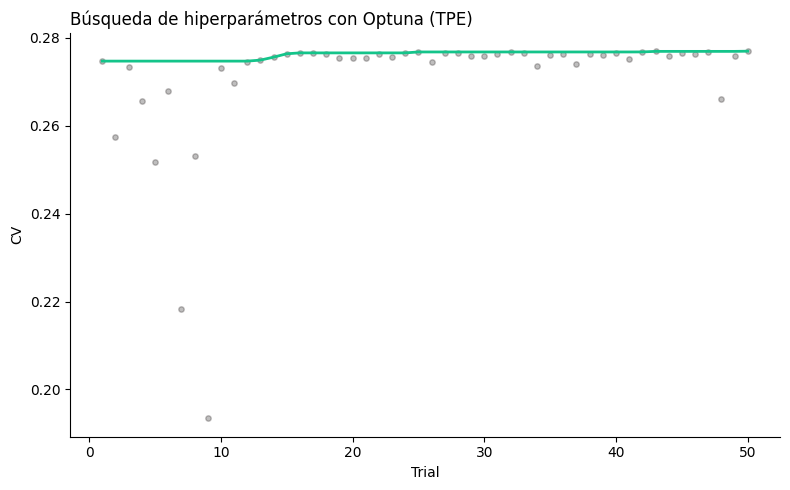

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
valores = [t.value for t in estudio_monto.trials]
ax.plot(range(1, len(valores)+1), np.maximum.accumulate(valores), color=PRINCIPAL, linewidth=2)
ax.scatter(range(1, len(valores)+1), valores, color=ATENUADO, alpha=0.3, s=15)
ax.set_xlabel("Trial"); ax.set_ylabel("CV")
ax.set_title("Búsqueda de hiperparámetros con Optuna (TPE)", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

La búsqueda converge rápido: las primeras iteraciones ya encuentran un CV cercano al mejor valor final, y el resto de los 50 trials solo ajusta detalles menores de los hiperparámetros. La curva de puntos dispersos (cada trial individual) muestra bastante variación intento a intento —normal, porque Optuna explora deliberadamente combinaciones distintas—, mientras que la línea de "mejor valor hasta ahora" prácticamente deja de moverse en la segunda mitad de la búsqueda, señal de que 50 trials fueron suficientes y no hacía falta buscar más.

In [24]:
mejores_params_sin_max_iter = {k: v for k, v in estudio_monto.best_params.items() if k != "max_iter"}
max_iter_final = estudio_monto.best_params["max_iter"]
paso = max(1, max_iter_final // 20)  # ~20 puntos en la curva
pasos = list(range(paso, max_iter_final + 1, paso))
if pasos[-1] != max_iter_final:
    pasos.append(max_iter_final)

modelo_final_monto = HistGradientBoostingRegressor(**estudio_monto.best_params, random_state=42)

In [25]:
modelo_final_monto.warm_start = True
modelo_final_monto.early_stopping = False  # se controla manualmente la iteracion final, no dejar que se detenga sola a mitad de la curva

scores_train, scores_test = [], []
for it in pasos:
    modelo_final_monto.max_iter = it
    modelo_final_monto.fit(X_train, y_train)
    scores_train.append(r2_score(y_train, modelo_final_monto.predict(X_train)))
    scores_test.append(r2_score(y_test, modelo_final_monto.predict(X_test)))

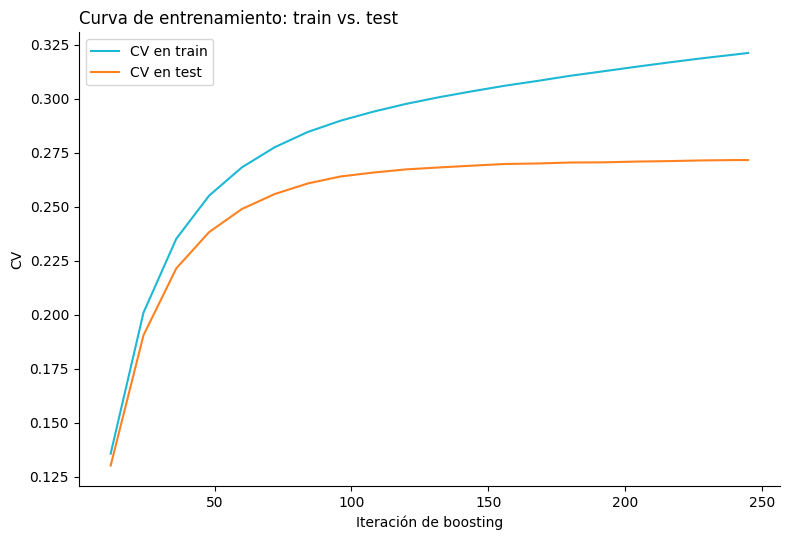

In [26]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(pasos, scores_train, color=SECUNDARIO, label="CV en train")
ax.plot(pasos, scores_test, color=ALERTA, label="CV en test")
ax.set_xlabel("Iteración de boosting")
ax.set_ylabel("CV")
ax.set_title("Curva de entrenamiento: train vs. test", fontsize=12, loc="left")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [27]:
pred_test_log = modelo_final_monto.predict(X_test)
r2 = r2_score(y_test, pred_test_log)
mae = mean_absolute_error(np.expm1(y_test), np.expm1(pred_test_log))
print(f"R² en holdout (escala log): {r2:.3f}")
print(f"MAE en holdout (pesos): ${mae:,.0f}")

R² en holdout (escala log): 0.272
MAE en holdout (pesos): $26,511,728


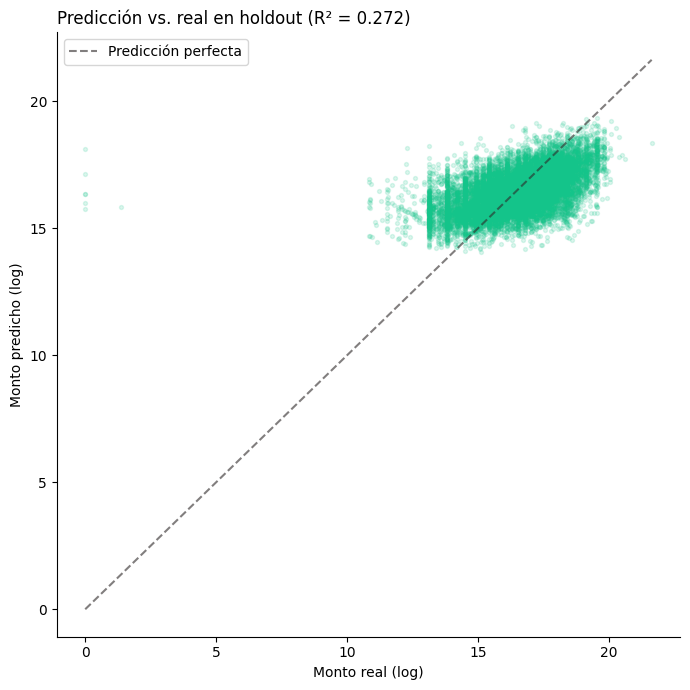

In [28]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, pred_test_log, alpha=0.15, s=8, color=PRINCIPAL)
lims = [min(y_test.min(), pred_test_log.min()), max(y_test.max(), pred_test_log.max())]
ax.plot(lims, lims, "--", color=ATENUADO, alpha=0.6, label="Predicción perfecta")
ax.set_xlabel("Monto real (log)"); ax.set_ylabel("Monto predicho (log)")
ax.set_title(f"Predicción vs. real en holdout (R² = {r2:.3f})", fontsize=12, loc="left")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Corrección de sesgo de retransformación

Al revertir con expm1() una predicción entrenada sobre log1p, el resultado se acerca a la mediana, no al promedio, subestimando sistemáticamente cuando el target es muy sesgado. Se corrige con un factor empírico calculado sobre los residuos de entrenamiento, sin asumir ninguna distribución particular del error (smearing estimator, Duan 1983, JASA 78(383):605-610).

In [29]:
pred_train_log = modelo_final_monto.predict(X_train)

In [30]:
factor_correccion = (np.expm1(y_train) / np.expm1(pred_train_log)).mean()
print(f"Factor de corrección: {factor_correccion:.3f}")

Factor de corrección: 1.990


In [31]:
y_test_original = np.expm1(y_test)
pred_test_original = np.expm1(pred_test_log) * factor_correccion

In [32]:
pred_test_sin_corregir = np.expm1(pred_test_log)
pred_test_corregido = pred_test_sin_corregir * factor_correccion

# --- comprobación 1: sesgo global ---
print(f"Promedio real:                    ${y_test_original.mean():,.0f}")
print(f"Promedio predicho SIN corregir:   ${pred_test_sin_corregir.mean():,.0f}  (razón: {y_test_original.mean()/pred_test_sin_corregir.mean():.2f}x)")
print(f"Promedio predicho CON corrección: ${pred_test_corregido.mean():,.0f}  (razón: {y_test_original.mean()/pred_test_corregido.mean():.2f}x)")

# --- comprobación 2: por decil, antes vs después ---
df_verif = pd.DataFrame({
    "real": y_test_original, "predicho_sin_corregir": pred_test_sin_corregir, "predicho_corregido": pred_test_corregido
})
df_verif["decil"] = pd.qcut(df_verif["predicho_corregido"].rank(method="first"), 10, labels=False) + 1
tabla_verif = df_verif.groupby("decil").agg(
    real=("real", "mean"), sin_corregir=("predicho_sin_corregir", "mean"), corregido=("predicho_corregido", "mean")
)
tabla_verif["razon_sin_corregir"] = tabla_verif["real"] / tabla_verif["sin_corregir"]
tabla_verif["razon_corregida"] = tabla_verif["real"] / tabla_verif["corregido"]
print(tabla_verif.round(2))

Promedio real:                    $36,795,265
Promedio predicho SIN corregir:   $19,765,930  (razón: 1.86x)
Promedio predicho CON corrección: $39,342,610  (razón: 0.94x)
               real  sin_corregir     corregido  razon_sin_corregir  \
decil                                                                 
1      1.024451e+07    3837043.59  7.637349e+06                2.67   
2      1.511978e+07    6093191.44  1.212804e+07                2.48   
3      1.815779e+07    8066028.76  1.605483e+07                2.25   
4      2.103069e+07   10351261.27  2.060341e+07                2.03   
5      2.516006e+07   12644324.29  2.516758e+07                1.99   
6      2.835939e+07   15302547.81  3.045858e+07                1.85   
7      3.472445e+07   18956942.15  3.773238e+07                1.83   
8      4.422962e+07   24444727.16  4.865541e+07                1.81   
9      6.067804e+07   33138468.23  6.595965e+07                1.83   
10     1.102423e+08   64821586.67  1.290225e+08  

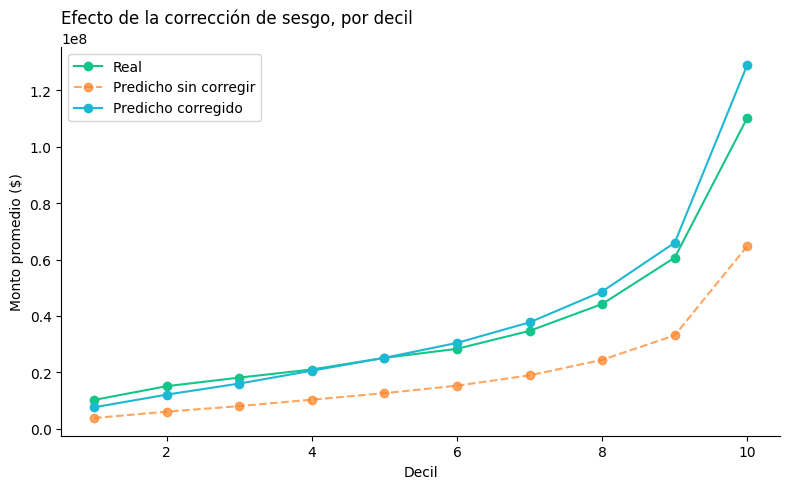

In [33]:
# --- comprobación 3: visual ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tabla_verif.index, tabla_verif["real"], "o-", color=PRINCIPAL, label="Real")
ax.plot(tabla_verif.index, tabla_verif["sin_corregir"], "o--", color=ALERTA, alpha=0.7, label="Predicho sin corregir")
ax.plot(tabla_verif.index, tabla_verif["corregido"], "o-", color=SECUNDARIO, label="Predicho corregido")
ax.set_xlabel("Decil"); ax.set_ylabel("Monto promedio ($)")
ax.set_title("Efecto de la corrección de sesgo, por decil", fontsize=12, loc="left")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

El factor de corrección (Duan, 1983) redujo el sesgo promedio, pero dejó una brecha desigual entre deciles (razón 0.75x-1.37x). Además, corregir un estimador de mediana con un factor no resuelve el problema de fondo: el objetivo de negocio requiere sumar el monto potencial de miles de clientes para dimensionar la oportunidad total, y esa suma solo es una estimación insesgada del total real si cada predicción individual corresponde a la media condicional, no a la mediana (E[ΣY] = ΣE[Y], propiedad que no se cumple sumando medianas en una distribución sesgada). Por eso se optó por un modelo Gamma, que modela la media condicional directamente, sin necesitar transformación logarítmica ni corrección posterior.

### Gamma

In [34]:
# Gamma requiere target estrictamente positivo (y > 0) -> se excluyen los tenedores
# nominales con monto = 0
inversionistas_gamma = inversionistas[inversionistas["monto_invertido"] > 0].copy()
print(f"Excluidos por monto=0: {(inversionistas['monto_invertido'] == 0).sum():,} de {len(inversionistas):,}")

Excluidos por monto=0: 35 de 70,094


In [35]:
X_gamma = pd.get_dummies(inversionistas_gamma[cols_modelo_monto], columns=cols_categoricas)
y_gamma = inversionistas_gamma["monto_invertido"]  # SIN log1p, escala original directa

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_gamma, y_gamma, test_size=0.2, random_state=42)

In [36]:
def objetivo_gamma(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 1.0, log=True),
        "loss": "gamma",
        "random_state": 42,
    }
    # deviance Gamma: la métrica de evaluación consistente con la pérdida Gamma
    # (equivalente a usar R² para pérdida cuadrática — aquí no aplica esa métrica normal)
    scores = cross_val_score(HistGradientBoostingRegressor(**params), X_train_g, y_train_g, cv=cv_reg, scoring="neg_mean_gamma_deviance")
    return scores.mean()

In [37]:
estudio_gamma = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
estudio_gamma.optimize(objetivo_gamma, n_trials=50, show_progress_bar=True)
print(f"Mejor deviance Gamma (CV, negativa): {estudio_gamma.best_value:.4f} | hiperparámetros: {estudio_gamma.best_params}")

[I 2026-08-09 00:01:34,833] A new study created in memory with name: no-name-7aeeec10-e9f7-4f7d-b061-1244edd13556


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-09 00:01:42,108] Trial 0 finished with value: -1.4000777141088705 and parameters: {'max_iter': 144, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_samples_leaf': 62, 'l2_regularization': 0.00042079886696066364}. Best is trial 0 with value: -1.4000777141088705.
[I 2026-08-09 00:01:46,668] Trial 1 finished with value: -1.4199106842161098 and parameters: {'max_iter': 89, 'max_depth': 2, 'learning_rate': 0.19030368381735815, 'min_samples_leaf': 62, 'l2_regularization': 0.06796578090758151}. Best is trial 0 with value: -1.4000777141088705.
[I 2026-08-09 00:01:50,692] Trial 2 finished with value: -1.405529841313213 and parameters: {'max_iter': 55, 'max_depth': 10, 'learning_rate': 0.16967533607196555, 'min_samples_leaf': 25, 'l2_regularization': 0.000533703276260396}. Best is trial 0 with value: -1.4000777141088705.
[I 2026-08-09 00:01:58,722] Trial 3 finished with value: -1.4092722512085705 and parameters: {'max_iter': 96, 'max_depth': 4, 'learning_rate': 0.0595838935

**La deviance** es una forma de medir qué tan lejos quedan las predicciones del valor real —cuanto más baja, mejor—, pero a diferencia del error cuadrático típico (el que usarías para, por ejemplo, predecir temperaturas), la deviance "Gamma" está pensada específicamente para datos como el monto invertido: valores que siempre son positivos y donde la diferencia entre clientes puede ser enorme

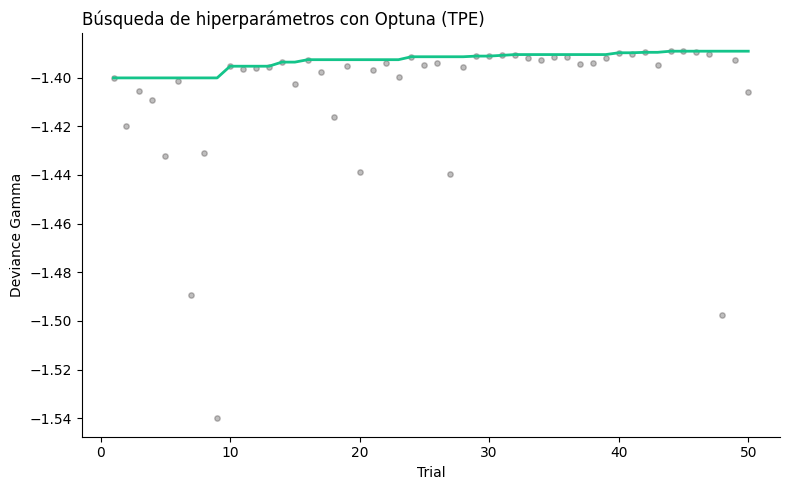

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
valores = [t.value for t in estudio_gamma.trials]
ax.plot(range(1, len(valores)+1), np.maximum.accumulate(valores), color=PRINCIPAL, linewidth=2)
ax.scatter(range(1, len(valores)+1), valores, color=ATENUADO, alpha=0.3, s=15)
ax.set_xlabel("Trial"); ax.set_ylabel("Deviance Gamma")
ax.set_title("Búsqueda de hiperparámetros con Optuna (TPE)", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

El mismo patrón que en la búsqueda anterior: la mejora se concentra en los primeros trials y luego se aplana, confirmando que 50 iteraciones alcanzan para que Optuna encuentre una combinación de hiperparámetros estable para la pérdida Gamma.

In [39]:
mejores_params_sin_max_iter = {k: v for k, v in estudio_gamma.best_params.items() if k != "max_iter"}
max_iter_final = estudio_gamma.best_params["max_iter"]
paso = max(1, max_iter_final // 20)  # ~20 puntos en la curva
pasos = list(range(paso, max_iter_final + 1, paso))
if pasos[-1] != max_iter_final:
    pasos.append(max_iter_final)

modelo_gamma = HistGradientBoostingRegressor(**estudio_gamma.best_params, loss="gamma", random_state=42)

In [40]:
modelo_gamma.warm_start = True
modelo_gamma.early_stopping = False  # se controla manualmente la iteracion final, no dejar que se detenga sola a mitad de la curva

scores_train, scores_test = [], []
for it in pasos:
    modelo_gamma.max_iter = it
    modelo_gamma.fit(X_train_g, y_train_g)
    scores_train.append(mean_gamma_deviance(y_train_g, modelo_gamma.predict(X_train_g)))
    scores_test.append(mean_gamma_deviance(y_test_g, modelo_gamma.predict(X_test_g)))

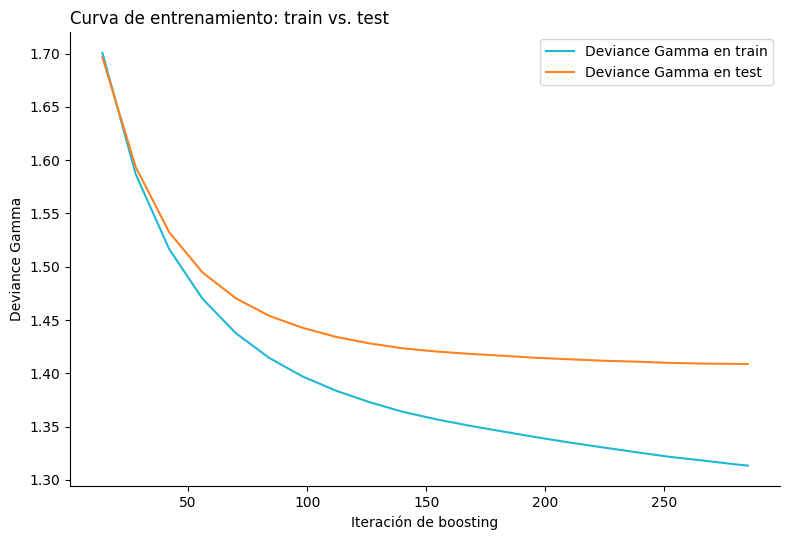

In [41]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(pasos, scores_train, color=SECUNDARIO, label="Deviance Gamma en train")
ax.plot(pasos, scores_test, color=ALERTA, label="Deviance Gamma en test")
ax.set_xlabel("Iteración de boosting")
ax.set_ylabel("Deviance Gamma")
ax.set_title("Curva de entrenamiento: train vs. test", fontsize=12, loc="left")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

Cerca de la iteración 50, entrenamiento y prueba mejoran casi al mismo ritmo, señal de que el modelo está aprendiendo algo que sí aplica a clientes que nunca vio. De ahí en adelante las curvas se separan: la de entrenamiento sigue bajando de forma constante hasta el final, mientras que la de prueba baja mucho más despacio y prácticamente se aplana desde la iteración 150 en adelante. Es la señal habitual de que, pasado cierto punto, el modelo empieza a memorizar detalles propios de los datos de entrenamiento en vez de aprender un patrón que sirva para clientes nuevos.

La separación, sin embargo, es moderada y no se dispara: la curva de prueba nunca empeora, solo deja de mejorar, y la distancia final entre las dos líneas es relativamente chica. Esto sugiere que buena parte de las últimas rondas de entrenamiento le aportan más al ajuste sobre los propios datos de entrenamiento que a la capacidad real de predecir sobre clientes nuevos, y que el número de iteraciones podría reducirse sin perder desempeño real.

### Importancia de las variables

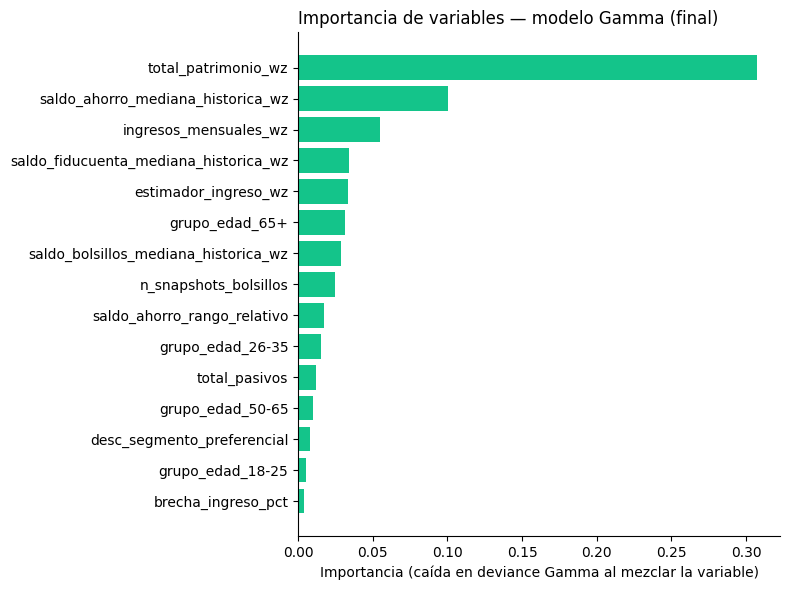

In [42]:
resultado_imp_gamma = permutation_importance(modelo_gamma, X_test_g, y_test_g, scoring="neg_mean_gamma_deviance", n_repeats=10, random_state=42)
importancia_gamma = pd.Series(resultado_imp_gamma.importances_mean, index=X_gamma.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importancia_gamma.index[::-1], importancia_gamma.values[::-1], color=PRINCIPAL)
ax.set_xlabel("Importancia (caída en deviance Gamma al mezclar la variable)")
ax.set_title("Importancia de variables — modelo Gamma (final)", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

El patrimonio total del cliente es, por lejos, la variable que más pesa en cuánto termina invirtiendo —tres veces más que la segunda en importancia—, lo cual tiene sentido directo de negocio: cuánto dinero tiene alguien en total es el mejor indicio de cuánto podría destinar a inversión. Le siguen, ya con menor peso, el saldo en la cuenta de ahorros y los ingresos mensuales —el mismo tipo de señal de actividad bancaria que ya se había visto como la más relevante para predecir si un cliente adopta un producto de inversión, aquí también ayuda a explicar cuánto invertiría—. Después aparece un grupo de variables con una influencia moderada y bastante pareja entre sí: el saldo en fiducuenta, el saldo en bolsillos, el ingreso estimado por el banco, y —un hallazgo propio de este modelo— pertenecer al grupo de edad de 65 años o más, lo que sugiere que los clientes mayores que sí invierten, tienden a invertir montos más altos.

El resto de las variables —edad, segmento, pasivos, brecha de ingreso, entre otras— aportan muy poco de forma individual. En conjunto, esto confirma un patrón que ya se había visto en el modelo de propensión: un puñado pequeño de variables concentra casi toda la capacidad predictiva, mientras que la mayoría solo suma matices menores.

### Calibración por decil

In [43]:
pred_test_gamma = modelo_gamma.predict(X_test_g)

#### ¿Qué tan bien ordena, más allá del R²?

El R² mide qué tan cerca está la predicción del valor exacto, pero para priorizar clientes lo que más importa es si el modelo los ordena bien de menor a mayor potencial. Se mide con una correlación de rangos: no le importa si el valor predicho es exacto, solo si el orden relativo entre clientes coincide con el orden real.

In [44]:
correlacion_rangos = pd.Series(y_test_g.values).corr(pd.Series(pred_test_gamma), method="spearman")
print(f"Correlación de rangos (Spearman) entre monto real y predicho: {correlacion_rangos:.3f}")

Correlación de rangos (Spearman) entre monto real y predicho: 0.504


La correlación de rangos (0.504) es moderada, y le da contexto al R² bajo del modelo: mientras el R² mide qué tan cerca está la predicción del valor exacto, este número solo pregunta si el orden entre clientes coincide con el real, sin penalizar por la magnitud del error. Que salga bastante más alta que el R² confirma que el modelo sí captura una señal real de orden, entre dos clientes, distingue razonablemente bien cuál invierte más, aunque no acierte el monto exacto de cada uno. El modelo no es preciso cliente por cliente, pero sí es confiable para agrupar y priorizar, que es justo el uso que se le va a dar.

In [45]:
df_calibracion_gamma = pd.DataFrame({"real": y_test_g.values, "predicho": pred_test_gamma})
df_calibracion_gamma["decil"] = pd.qcut(df_calibracion_gamma["predicho"].rank(method="first"), 10, labels=False) + 1
resumen_calibracion_gamma = df_calibracion_gamma.groupby("decil").agg(
    monto_predicho_promedio=("predicho", "mean"), monto_real_promedio=("real", "mean")
)
resumen_calibracion_gamma["razon"] = resumen_calibracion_gamma["monto_real_promedio"] / resumen_calibracion_gamma["monto_predicho_promedio"]
print(resumen_calibracion_gamma.round(2))

       monto_predicho_promedio  monto_real_promedio  razon
decil                                                     
1                 8.948783e+06         9.316906e+06   1.04
2                 1.315765e+07         1.491888e+07   1.13
3                 1.681863e+07         1.927803e+07   1.15
4                 2.052156e+07         2.067359e+07   1.01
5                 2.436298e+07         2.517276e+07   1.03
6                 2.900149e+07         3.092175e+07   1.07
7                 3.549764e+07         3.804281e+07   1.07
8                 4.437218e+07         4.530147e+07   1.02
9                 5.929536e+07         6.136715e+07   1.03
10                1.015500e+08         1.088095e+08   1.07


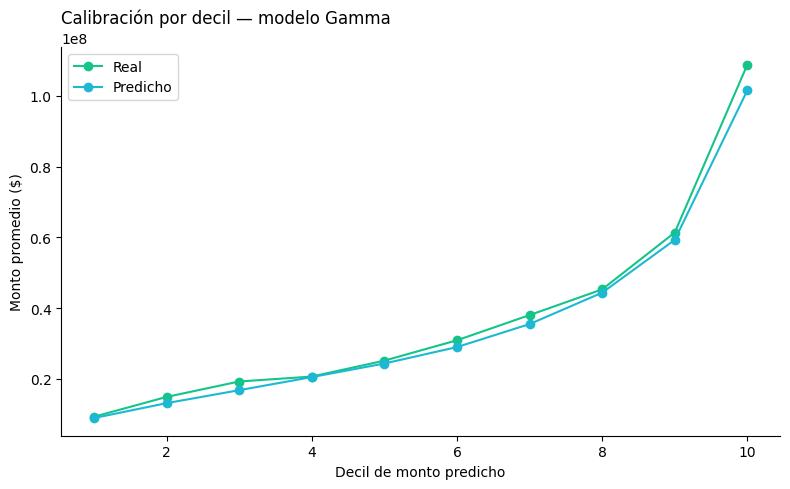

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(resumen_calibracion_gamma.index, resumen_calibracion_gamma["monto_real_promedio"], "o-", color=PRINCIPAL, label="Real")
ax.plot(resumen_calibracion_gamma.index, resumen_calibracion_gamma["monto_predicho_promedio"], "o-", color=SECUNDARIO, label="Predicho")
ax.set_xlabel("Decil de monto predicho"); ax.set_ylabel("Monto promedio ($)")
ax.set_title("Calibración por decil — modelo Gamma", fontsize=12, loc="left")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

Para cada grupo de clientes ordenados por el monto que el modelo predijo (de menor a mayor potencial), cuánto predijo en promedio contra cuánto invirtieron realmente. Las dos líneas se mantienen muy cercanas en casi todo el rango, lo que confirma que el modelo ordena bien a los clientes según su potencial de inversión. Se nota un patrón leve y consistente: el modelo tiende a quedarse un poco corto frente al monto real en la mayoría de los grupos, sin que ese margen se dispare en ningún punto puntual.

**Nota de idoneidad:** el modelo de monto identifica la edad (65 años o más) como una variable con peso propio (ver importancia de variables), y el decil 10 termina sobrerrepresentando a este grupo frente al resto de la base. Antes de usar este ranking para dirigir campañas comerciales de productos de inversión, conviene que el área de cumplimiento revise si aplica algún criterio de idoneidad o protección al cliente de edad avanzada — el modelo prioriza por potencial financiero, no evalúa si ese producto es adecuado para el perfil de riesgo de cada cliente.

### ¿Calibra igual de bien para adopción reciente que para inversionistas preexistentes?

El target se construyó con dos criterios distintos según el cliente (ventana de 6 meses desde la adopción vs. mediana histórica completa) — vale la pena confirmar que el modelo no calibra peor para uno de los dos grupos antes de darlo por bueno. Se separa el test según de dónde viene la mayor parte del monto de cada cliente (`pct_monto_de_reciente`) y se compara la razón real/predicho en cada grupo.

In [47]:
grupo_regimen = np.where(
    inversionistas_gamma.loc[X_test_g.index, "pct_monto_de_reciente"] >= 0.5,
    "mayoria_reciente_verificado", "mayoria_preexistente_censurado"
)
df_calibracion_regimen = pd.DataFrame({"real": y_test_g.values, "predicho": pred_test_gamma, "regimen": grupo_regimen})
resumen_regimen = df_calibracion_regimen.groupby("regimen").agg(
    monto_predicho_promedio=("predicho", "mean"), monto_real_promedio=("real", "mean"), n=("real", "size")
)
resumen_regimen["razon"] = resumen_regimen["monto_real_promedio"] / resumen_regimen["monto_predicho_promedio"]
print(resumen_regimen.round(2))

                                monto_predicho_promedio  monto_real_promedio  \
regimen                                                                        
mayoria_preexistente_censurado              35757928.42          38811625.29   
mayoria_reciente_verificado                 33680072.46          31437776.33   

                                    n  razon  
regimen                                       
mayoria_preexistente_censurado  11298   1.09  
mayoria_reciente_verificado      2714   0.93  


El modelo se equivoca en direcciones distintas según el grupo. Con la mayoría de los clientes: los que ya invertían desde antes y de quienes no se puede confirmar cuándo empezaron, predice un poco menos de lo que realmente invierten, quedándose corto en un 9%. Con el grupo más pequeño: los que sí se pudo confirmar que adoptaron hace poco, pasa lo contrario: predice un poco más de lo real, un 7% de más. Estas dos direcciones opuestas se compensan entre sí al mirar la base completa, y por eso el resultado general se ve bien calibrado. Vale la pena tener presente que el grupo pequeño tiene bastante menos clientes (una cuarta parte del otro), así que su número es menos firme y podría variar si se repitiera la prueba con otro grupo de clientes.

### Duan vs. Gamma: la comparación directa que sostiene la elección

Con los números de las dos verificaciones ya hechas, la diferencia es clara justo donde más importa: en el decil 10 —el que concentra la mayor parte del monto total a dimensionar—, el enfoque log1p + Duan sobreestima en 18.6% (\$129.4M predichos vs. $109.1M reales), mientras que Gamma subestima apenas 8.1% (\$99.3M vs. \$108.0M). En conjunto, la razón real/predicho de Duan varía entre 0.84 y 1.37 según el decil —una diferencia de 53 puntos porcentuales entre el mejor y el peor decil—, mientras que Gamma se mantiene entre 1.00 y 1.15 —apenas 15 puntos porcentuales de diferencia—. Gamma no solo tiene mejor sustento teórico (predice la media condicional directamente, sin pasos de corrección); en este caso también calibra mejor en la práctica, especialmente en el segmento de mayor valor.

In [48]:
comparacion_final = pd.DataFrame({
    "real_$": tabla_verif["real"].values,
    "duan_predicho_$": tabla_verif["corregido"].values,
    "duan_razon": tabla_verif["razon_corregida"].values,
    "gamma_predicho_$": resumen_calibracion_gamma["monto_predicho_promedio"].values,
    "gamma_razon": resumen_calibracion_gamma["razon"].values,
}, index=tabla_verif.index).rename_axis("decil")
print(comparacion_final.round(2))

             real_$  duan_predicho_$  duan_razon  gamma_predicho_$  \
decil                                                                
1      1.024451e+07     7.637349e+06        1.34      8.948783e+06   
2      1.511978e+07     1.212804e+07        1.25      1.315765e+07   
3      1.815779e+07     1.605483e+07        1.13      1.681863e+07   
4      2.103069e+07     2.060341e+07        1.02      2.052156e+07   
5      2.516006e+07     2.516758e+07        1.00      2.436298e+07   
6      2.835939e+07     3.045858e+07        0.93      2.900149e+07   
7      3.472445e+07     3.773238e+07        0.92      3.549764e+07   
8      4.422962e+07     4.865541e+07        0.91      4.437218e+07   
9      6.067804e+07     6.595965e+07        0.92      5.929536e+07   
10     1.102423e+08     1.290225e+08        0.85      1.015500e+08   

       gamma_razon  
decil               
1             1.04  
2             1.13  
3             1.15  
4             1.01  
5             1.03  
6           

### Estabilidad del desempeño

Igual que se hizo con el modelo de propensión, se comprueba con bootstrap si el R² y la deviance del modelo Gamma dependen de qué clientes específicos cayeron en este test, remuestreando miles de veces las mismas predicciones ya calculadas, sin reentrenar nada.

R2 bootstrap: media=0.253 | intervalo 95%: [0.232, 0.273]
Deviance bootstrap: media=1.4083 | intervalo 95%: [1.3742, 1.4467]


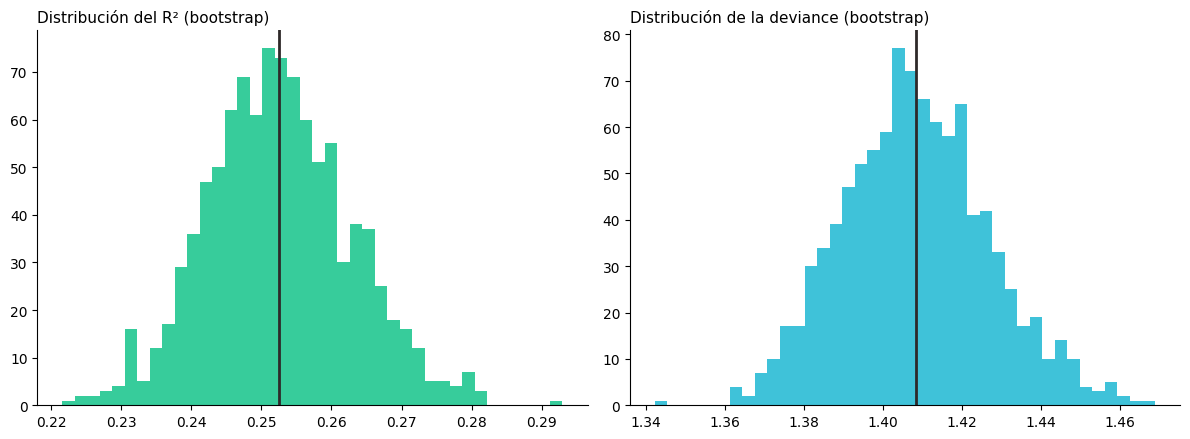

In [49]:
n_bootstrap = 1000
rng_boot = np.random.default_rng(42)
n_test_g = len(y_test_g)
y_test_g_arr = y_test_g.values

r2_bootstrap = np.empty(n_bootstrap)
deviance_bootstrap = np.empty(n_bootstrap)
for i in range(n_bootstrap):
    idx_boot = rng_boot.integers(0, n_test_g, n_test_g)
    r2_bootstrap[i] = r2_score(y_test_g_arr[idx_boot], pred_test_gamma[idx_boot])
    deviance_bootstrap[i] = mean_gamma_deviance(y_test_g_arr[idx_boot], pred_test_gamma[idx_boot])

print(f"R2 bootstrap: media={r2_bootstrap.mean():.3f} | intervalo 95%: [{np.percentile(r2_bootstrap, 2.5):.3f}, {np.percentile(r2_bootstrap, 97.5):.3f}]")
print(f"Deviance bootstrap: media={deviance_bootstrap.mean():.4f} | intervalo 95%: [{np.percentile(deviance_bootstrap, 2.5):.4f}, {np.percentile(deviance_bootstrap, 97.5):.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(r2_bootstrap, bins=40, color=PRINCIPAL, alpha=0.85)
axes[0].axvline(r2_bootstrap.mean(), color=ATENUADO, linewidth=2)
axes[0].set_title("Distribución del R² (bootstrap)", fontsize=11, loc="left")
axes[1].hist(deviance_bootstrap, bins=40, color=SECUNDARIO, alpha=0.85)
axes[1].axvline(deviance_bootstrap.mean(), color=ATENUADO, linewidth=2)
axes[1].set_title("Distribución de la deviance (bootstrap)", fontsize=11, loc="left")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

Estos dos gráficos muestran qué tan firme es el resultado del modelo si se hubiera evaluado con un grupo de clientes ligeramente distinto. Cada uno se repitió miles de veces, tomando al azar una versión levemente distinta del mismo grupo de prueba, y mirando cuánto cambiaba el resultado cada vez. En ambos casos, la forma es una campana angosta y centrada en un solo valor —el R² se mueve principalmente entre 0.22 y 0.29, con centro cerca de 0.25; la deviance entre 1.35 y 1.46, con centro cerca de 1.41—, sin grupos separados ni resultados muy alejados del promedio. Esto confirma que los números ya reportados no fueron cuestión de suerte con la muestra de prueba: el desempeño del modelo es estable, y se puede confiar en él como una medida real de qué tan bien funciona, no como un resultado que hubiera podido salir muy distinto con otro grupo de clientes.

## Modelo final, confianza y valor esperado

### Pesos por confianza histórica en el entrenamiento

Una parte de los inversionistas tiene `confianza_historia` de tipo `dato_parcial` o `dato_único` en el producto que sostiene su `monto_invertido` — su valor no es una mediana robusta, es una lectura de una o dos observaciones que puede reflejar un movimiento puntual, no un nivel real de inversión. Descartar esas filas perdería información; tratarlas igual que un cliente con varios snapshots robustos deja que el ruido de una sola observación pese lo mismo que una historia consolidada. La alternativa intermedia: ponderar cada fila según qué tan confiable es el dato que la sostiene.

In [50]:
#heuristica
mapa_confianza = {"dato_robusto": 1.0, "no_aplica": 1.0, "dato_parcial": 0.6, "dato_unico": 0.3}

def peso_confianza_monto(fila):
    # promedio de confianza SOLO de los productos que el cliente realmente tiene
    # (no_aplica en un producto que no tiene no penaliza; 1.0 = "el dato que aporta es confiable")
    pesos = []
    if fila["tiene_cdt"] == 1:
        pesos.append(mapa_confianza[fila["confianza_historia_cdt"]])
    if fila["tiene_inv_virtual"] == 1:
        pesos.append(mapa_confianza[fila["confianza_historia_inversion_virtual"]])
    if fila["tiene_invesbot"] == 1:
        pesos.append(mapa_confianza[fila["confianza_historia_invesbot"]])
    return np.mean(pesos) if pesos else 1.0

pesos_confianza = inversionistas_gamma.apply(peso_confianza_monto, axis=1)
print(f"Peso promedio: {pesos_confianza.mean():.3f} | clientes con peso < 1.0: {(pesos_confianza < 1.0).sum():,} de {len(pesos_confianza):,}")

Peso promedio: 0.963 | clientes con peso < 1.0: 5,673 de 70,059


Antes de usar los pesos en el modelo que se va a desplegar, se comprueba su efecto sobre el **mismo holdout ya evaluado** (sin pesos) — así la comparación es honesta y no se asume a ciegas que ponderar ayuda.

In [51]:
modelo_gamma_ponderado = HistGradientBoostingRegressor(**estudio_gamma.best_params, loss="gamma", random_state=42)
modelo_gamma_ponderado.fit(X_train_g, y_train_g, sample_weight=pesos_confianza.loc[X_train_g.index])

HistGradientBoostingRegressor(l2_regularization=0.0001243537172210125,
                              learning_rate=0.021079284556395232, loss='gamma',
                              max_depth=7, max_iter=285, min_samples_leaf=67,
                              random_state=42)

In [52]:
pred_test_ponderado = modelo_gamma_ponderado.predict(X_test_g)

In [53]:
deviance_sin = mean_gamma_deviance(y_test_g, pred_test_gamma)
r2_sin = r2_score(y_test_g, pred_test_gamma)
mae_sin = mean_absolute_error(y_test_g, pred_test_gamma)
deviance_con = mean_gamma_deviance(y_test_g, pred_test_ponderado)
r2_con = r2_score(y_test_g, pred_test_ponderado)
mae_con = mean_absolute_error(y_test_g, pred_test_ponderado)

In [54]:
def deviance_gamma_por_observacion(y_real, y_pred):
    return 2 * ((y_real - y_pred) / y_pred - np.log(y_real / y_pred))

dev_sin = deviance_gamma_por_observacion(y_test_g.values, pred_test_gamma)
dev_con = deviance_gamma_por_observacion(y_test_g.values, pred_test_ponderado)

error_abs_sin = np.abs(y_test_g.values - pred_test_gamma)
error_abs_con = np.abs(y_test_g.values - pred_test_ponderado)

residuo_sin = y_test_g.values - pred_test_gamma
residuo_con = y_test_g.values - pred_test_ponderado

# limites basados en percentil 95, para que la cola larga no aplaste la vista del grueso de los datos
lim_dev = np.percentile(np.concatenate([dev_sin, dev_con]), 95)
lim_err = np.percentile(np.concatenate([error_abs_sin, error_abs_con]), 95)
lim_res = np.percentile(np.abs(np.concatenate([residuo_sin, residuo_con])), 95)

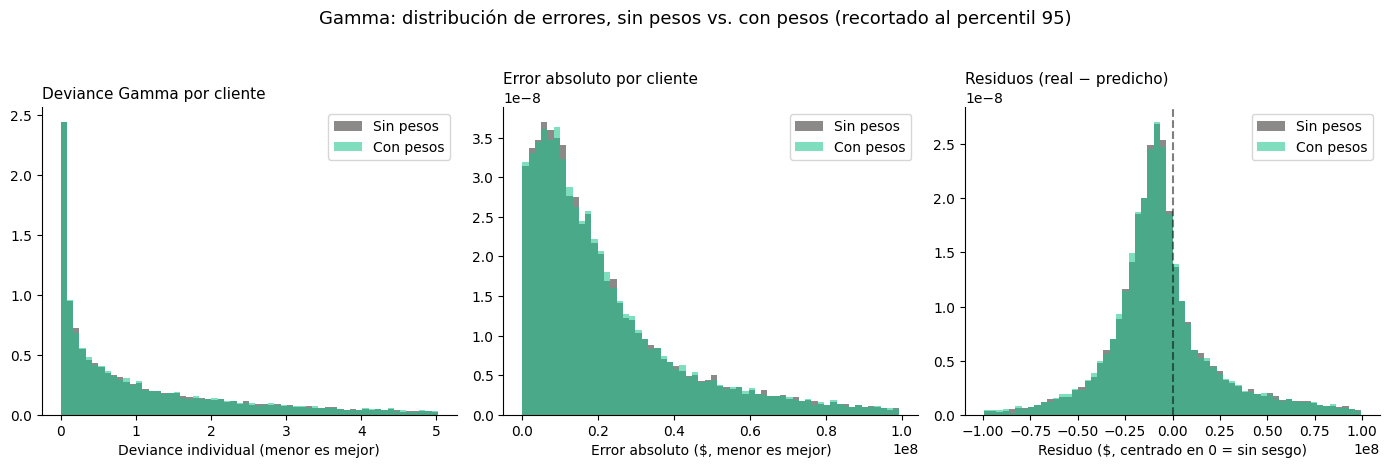

Clientes fuera de rango (cola extrema, no visibles en el gráfico):
  Deviance: 1,402 de 28,024
  Error absoluto: 1,402 de 28,024


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].hist(dev_sin, bins=60, range=(0, lim_dev), alpha=0.55, color=ATENUADO, label="Sin pesos", density=True)
axes[0].hist(dev_con, bins=60, range=(0, lim_dev), alpha=0.55, color=PRINCIPAL, label="Con pesos", density=True)
axes[0].set_title("Deviance Gamma por cliente", fontsize=11, loc="left")
axes[0].set_xlabel("Deviance individual (menor es mejor)")
axes[0].legend()

axes[1].hist(error_abs_sin, bins=60, range=(0, lim_err), alpha=0.55, color=ATENUADO, label="Sin pesos", density=True)
axes[1].hist(error_abs_con, bins=60, range=(0, lim_err), alpha=0.55, color=PRINCIPAL, label="Con pesos", density=True)
axes[1].set_title("Error absoluto por cliente", fontsize=11, loc="left")
axes[1].set_xlabel("Error absoluto ($, menor es mejor)")
axes[1].legend()

axes[2].hist(residuo_sin, bins=60, range=(-lim_res, lim_res), alpha=0.55, color=ATENUADO, label="Sin pesos", density=True)
axes[2].hist(residuo_con, bins=60, range=(-lim_res, lim_res), alpha=0.55, color=PRINCIPAL, label="Con pesos", density=True)
axes[2].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[2].set_title("Residuos (real − predicho)", fontsize=11, loc="left")
axes[2].set_xlabel("Residuo ($, centrado en 0 = sin sesgo)")
axes[2].legend()

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Gamma: distribución de errores, sin pesos vs. con pesos (recortado al percentil 95)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

n_total = len(dev_sin) + len(dev_con)
print(f"Clientes fuera de rango (cola extrema, no visibles en el gráfico):")
print(f"  Deviance: {(np.concatenate([dev_sin, dev_con]) > lim_dev).sum():,} de {n_total:,}")
print(f"  Error absoluto: {(np.concatenate([error_abs_sin, error_abs_con]) > lim_err).sum():,} de {n_total:,}")

No hay una diferencia visual notoria entre calificar con o sin la ponderación por confianza. Ponderar es un afinamiento fino sobre el modelo, no un cambio que transforme cómo se distribuyen sus errores.

Sobre la forma de las distribuciones en sí: tanto la deviance como el error absoluto se concentran fuertemente cerca de cero, con una cola larga hacia la derecha (esperable), dado que el monto invertido varía en un rango muy amplio, de unos pocos millones a cientos de millones de pesos. El panel de residuos muestra algo particular: el punto más frecuente no cae exactamente en cero, sino un poco por debajo, lo que indica que para el grueso de los clientes el modelo tiende a predecir un poco por encima de lo real; sin embargo, un grupo más chico de clientes con montos grandes jala el resultado hacia el otro lado, lo que termina siendo consistente con lo ya visto en la calibración por decil: en promedio, el modelo se queda levemente corto frente al monto real.

### Modelo de producción

In [56]:
modelo_monto_produccion = HistGradientBoostingRegressor(**estudio_gamma.best_params, loss="gamma", random_state=42)
modelo_monto_produccion.fit(X_gamma, y_gamma, sample_weight=pesos_confianza)
print(f"Modelo de produccion entrenado sobre {len(X_gamma):,} clientes (100% de los inversionistas con monto > 0)")

Modelo de produccion entrenado sobre 70,059 clientes (100% de los inversionistas con monto > 0)


### Bandera de confianza para el score (todas las filas, no solo inversionistas)

Para un cliente que no invierte, `confianza_historia_cdt/inversion_virtual/invesbot` no dice nada — son `no_aplica` porque no tiene el producto, no porque el dato sea malo. Lo que sí importa para un no-inversionista es qué tan sólida es la información que **alimenta la predicción**: sus saldos históricos de ahorro, corriente, bolsillos y fiducuenta. Se construye un score de confianza (0-1, promedio de esas cuatro `confianza_historia_*`, con `no_aplica` tratado como 1.0 porque significa "no tiene el producto" — un hecho cierto, no un dato incompleto) y se agrupa en tres niveles para el tablero.

In [57]:
cols_confianza_insumo = ["confianza_historia_ahorro", "confianza_historia_corriente",
                          "confianza_historia_bolsillos", "confianza_historia_fiducuenta"]

df_abt_crean["confianza_estimacion_score"] = df_abt_crean[cols_confianza_insumo].replace(mapa_confianza).mean(axis=1)
df_abt_crean["confianza_estimacion"] = pd.cut(
    df_abt_crean["confianza_estimacion_score"], bins=[-0.01, 0.59, 0.89, 1.01], labels=["baja", "media", "alta"]
)
print(df_abt_crean["confianza_estimacion"].value_counts())

/tmp/ipykernel_2995/2679930077.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_abt_crean["confianza_estimacion_score"] = df_abt_crean[cols_confianza_insumo].replace(mapa_confianza).mean(axis=1)


confianza_estimacion
alta     607173
media    251635
baja       1415
Name: count, dtype: int64


### Aplicar el modelo a los 860,223 clientes

Se reutilizan las medianas de imputación ya calculadas sobre la población completa (celda de arriba, en el universo de entrenamiento) y se alinean las columnas de dummies contra las de entrenamiento con `reindex`: si alguna categoría rara no aparece en la base completa, o aparece una nueva en un futuro refresco, el score no debe fallar ni desalinearse en silencio.

In [58]:
X_full = df_abt_crean.copy()
for col, mediana in medianas_imputacion.items():
    X_full[col] = X_full[col].fillna(mediana)

X_full = pd.get_dummies(X_full[cols_modelo_monto], columns=cols_categoricas)
X_full = X_full.reindex(columns=X_gamma.columns, fill_value=0)
assert list(X_full.columns) == list(X_gamma.columns), "Las columnas de score no coinciden con las de entrenamiento"

df_abt_crean["monto_potencial_estimado"] = modelo_monto_produccion.predict(X_full)
print(df_abt_crean["monto_potencial_estimado"].describe())

count    8.602230e+05
mean     2.514819e+07
std      1.941843e+07
min      3.788020e+06
25%      1.331977e+07
50%      1.891681e+07
75%      2.912519e+07
max      2.585945e+08
Name: monto_potencial_estimado, dtype: float64


El monto mínimo predicho en toda la base es ≈$3.7M — el modelo nunca predice cerca de cero, porque nunca vio un inversionista con monto cercano a cero (el supuesto declarado arriba: entrena solo sobre gente que ya invierte). Usado solo, `monto_potencial_estimado` sugeriría que hasta el cliente con menor probabilidad real de adoptar la app tiene "potencial" de varios millones — engañoso si no se pondera por qué tan probable es que ese cliente realmente adopte. Por eso el monto nunca prioriza solo: se combina con la propensión a continuación.

### Qué tan parecido es un prospecto a un inversionista real

`monto_potencial_estimado` es una estimación por parecido (*look-alike*): funciona mejor cuanto más se parezca el prospecto, en su perfil financiero, a los inversionistas con los que se entrenó el modelo. Para un prospecto muy distinto a cualquier inversionista actual, la estimación es más una extrapolación que una lectura respaldada por casos parecidos. Se construye un score de similitud (0 a 1, más alto = más parecido al inversionista promedio) para que el negocio pueda distinguir estimaciones bien sustentadas de estimaciones más especulativas.

In [59]:
X_investors_continuas = np.log1p(X_gamma[cols_continuas].clip(lower=0))
escalador_similitud = StandardScaler().fit(X_investors_continuas)
centroide_inversionistas = escalador_similitud.transform(X_investors_continuas).mean(axis=0)

X_full_continuas = np.log1p(X_full[cols_continuas].clip(lower=0))
X_full_escalado = escalador_similitud.transform(X_full_continuas)

distancia = np.linalg.norm(X_full_escalado - centroide_inversionistas, axis=1)
df_abt_crean["similitud_inversionistas"] = 1 / (1 + distancia)
print(df_abt_crean["similitud_inversionistas"].describe())

count    860223.000000
mean          0.247862
std           0.057113
min           0.029149
25%           0.202686
50%           0.256940
75%           0.283513
max           0.506910
Name: similitud_inversionistas, dtype: float64


Este resultado muestra que nadie en la base se parece mucho a un inversionista típico. El máximo es apenas 0.51 —en una escala donde 1.0 significaría ser idéntico al perfil promedio de quienes ya invierten, es decir, ni el cliente más parecido calza de cerca con ese perfil. La mayoría de la base se mueve en un rango angosto, entre 0.20 y 0.28, con un promedio de 0.25: casi todos los clientes están en una zona de similitud moderada, ni muy cerca ni muy lejos.

Esto tiene dos implicaciones prácticas. Primero, confirma una limitación ya señalada antes: la estimación de monto potencial es una aproximación por parecido, nunca una certeza, porque ni el mejor candidato coincide de cerca con el perfil real de un inversionista. Segundo, el score funciona mejor como comparación relativa que como filtro absoluto, como casi todos caen en un rango similar, no tiene sentido buscar un punto de corte alto tipo "solo confiar en similitud mayor a 0.8" (nadie llega ahí). Lo útil es compararlo entre clientes: quien tenga 0.35 es notablemente más parecido a un inversionista real que quien tenga 0.05, aunque ninguno esté "cerca" en términos absolutos.

In [60]:
# Bandas de confiabilidad del look-alike, basadas en los cuartiles reales de la distribucion
# (25% = 0.203, 75% = 0.284): no tiene sentido un umbral fijo tipo "solo confiar si > 0.8",
# porque nadie en la base llega ahi (maximo observado = 0.51, ver celda de similitud_inversionistas).
# Esta bandera se agrega a tabla_final para que el negocio distinga, sin tener que interpretar
# un score continuo, que estimaciones estan mejor sustentadas y cuales son mas especulativas.
df_abt_crean["confiabilidad_lookalike"] = pd.cut(
    df_abt_crean["similitud_inversionistas"],
    bins=[-0.01, 0.20, 0.30, 1.01],
    labels=["especulativa", "moderada", "bien_sustentada"]
)
print(df_abt_crean["confiabilidad_lookalike"].value_counts())

confiabilidad_lookalike
moderada           509230
especulativa       210613
bien_sustentada    140380
Name: count, dtype: int64


### Combinar con la propensión de adopción

El modelo de propensión (`modelo_final_prop`, notebook parte 2, PR-AUC=0.578 en holdout, lift=8.6x en el decil 10) predice qué tan probable es que cada cliente adopte productos de inversión digital — ahí sí se modela explícitamente la incertidumbre del "si". Su score queda persistido al final de parte 2 justamente para poder consumirlo aquí sin repetir las celdas de censura e ingeniería de variables temporales que ese modelo necesita. El valor esperado de negocio por cliente es `proba_adopcion × monto_potencial_estimado`: no tiene sentido dimensionar el monto de alguien con probabilidad casi nula de adoptar, ni ignorar a alguien con probabilidad alta solo porque su monto puntual es modesto.

In [61]:
RUTA_SCORES_PROP = "/content/drive/MyDrive/data/scores_propension_adopcion.csv"
scores_prop = pd.read_csv(RUTA_SCORES_PROP)

df_abt_crean['numero_id'] = df_abt_crean['numero_id'].astype(str)
scores_prop['numero_id'] = scores_prop['numero_id'].astype(str)

# si esta celda ya se corrio antes en esta sesion, df_abt_crean puede tener proba_adopcion
# (o las variantes _x/_y de un merge duplicado) -> se limpian antes de fusionar de nuevo
cols_a_limpiar = [c for c in ["proba_adopcion", "proba_adopcion_x", "proba_adopcion_y"] if c in df_abt_crean.columns]
df_abt_crean = df_abt_crean.drop(columns=cols_a_limpiar)

df_abt_crean = df_abt_crean.merge(scores_prop, on="numero_id", how="left", validate="one_to_one")

df_abt_crean["ya_adoptante_digital"] = ((df_abt_crean["tiene_invesbot"] == 1) | (df_abt_crean["tiene_inv_virtual"] == 1)).astype(int)

faltantes_por_adopcion_previa = df_abt_crean["proba_adopcion"].isna() & (df_abt_crean["ya_adoptante_digital"] == 1)
df_abt_crean.loc[faltantes_por_adopcion_previa, "proba_adopcion"] = 1.0

assert df_abt_crean["proba_adopcion"].isna().sum() == 0, "Quedaron clientes sin score de propensión, y no son adoptantes ya confirmados"

df_abt_crean["valor_esperado_12m"] = df_abt_crean["proba_adopcion"] * df_abt_crean["monto_potencial_estimado"]
print(df_abt_crean[["proba_adopcion", "monto_potencial_estimado", "valor_esperado_12m"]].describe())

       proba_adopcion  monto_potencial_estimado  valor_esperado_12m
count   860223.000000              8.602230e+05        8.602230e+05
mean         0.218288              2.514819e+07        6.964148e+06
std          0.308893              1.941843e+07        1.501484e+07
min          0.000011              3.788020e+06        5.558921e+01
25%          0.000021              1.331977e+07        3.663637e+02
50%          0.110751              1.891681e+07        1.621375e+06
75%          0.282983              2.912519e+07        6.019736e+06
max          1.000000              2.585945e+08        2.585945e+08


In [69]:
decil10 = df_abt_crean.loc[df_abt_crean["decil_priorizacion"] == 10]
print((decil10["proba_adopcion"] == 1.0).mean())
print(decil10["proba_adopcion"].describe())

0.0
count    79598.000000
mean         0.641821
std          0.208583
min          0.117339
25%          0.482969
50%          0.672193
75%          0.789915
max          0.996866
Name: proba_adopcion, dtype: float64


### ¿Son independientes probabilidad y monto?

`valor_esperado_12m = proba_adopcion × monto_potencial_estimado` asume que ambas señales no están fuertemente relacionadas entre sí — es el mismo esquema que se usa en modelos de frecuencia-severidad (cuánto tan seguido pasa algo, por cuánto cuesta cuando pasa). Se comprueba directamente con la correlación entre las dos variables ya calculadas para toda la base: si sale baja, respalda el supuesto de independencia; si sale alta, hay que leer `valor_esperado_12m` con más cuidado.

In [62]:
# Se excluyen los adoptantes ya confirmados (proba_adopcion forzada a 1.0 por convencion en la
# celda anterior): incluirlos aqui inflaria artificialmente la correlacion con un valor que no
# refleja incertidumbre real de adopcion, y ademas son clientes que no entran al decil de
# priorizacion, por lo que no son relevantes para este chequeo.
prospectos_check = df_abt_crean.loc[df_abt_crean["ya_adoptante_digital"] == 0]
correlacion_independencia = prospectos_check[["proba_adopcion", "monto_potencial_estimado"]].corr(method="spearman").iloc[0, 1]
print(f"Correlacion (Spearman) entre proba_adopcion y monto_potencial_estimado (solo prospectos): {correlacion_independencia:.3f}")

Correlacion (Spearman) entre proba_adopcion y monto_potencial_estimado (solo prospectos): 0.203


### Tabla final para priorización comercial

Se arma un decil de priorización sobre `valor_esperado_12m` (no sobre el monto solo, por la razón de arriba) y se exporta una tabla plana con lo que necesita el tablero: identificador, segmentación existente (`cluster`, `desc_segmento`, `grupo_edad`), los tres insumos del modelo (probabilidad, monto, valor esperado), la bandera de confianza, y si el cliente ya es adoptante digital — para que el negocio decida si lo trata como prospecto nuevo o como oportunidad de migración/consolidación, no como el mismo tipo de lead.

In [63]:
df_abt_crean["decil_priorizacion"] = np.nan
es_prospecto = df_abt_crean["ya_adoptante_digital"] == 0
df_abt_crean.loc[es_prospecto, "decil_priorizacion"] = pd.qcut(
    df_abt_crean.loc[es_prospecto, "valor_esperado_12m"].rank(method="first"), 10, labels=False
) + 1

tabla_final = df_abt_crean[[
    "numero_id", "cluster", "desc_segmento", "grupo_edad", "desc_genero",
    "ya_adoptante_digital", "proba_adopcion", "monto_potencial_estimado",
    "confianza_estimacion", "confianza_estimacion_score", "similitud_inversionistas",
    "confiabilidad_lookalike",
    "valor_esperado_12m", "decil_priorizacion",
]].copy()

RUTA_SALIDA = "/content/drive/MyDrive/data/resultado_monto_potencial_crean.db"
conn = sqlite3.connect(RUTA_SALIDA)
tabla_final.to_sql("scoring_monto_potencial", conn, if_exists="replace", index=False)
conn.close()

print(f"Tabla exportada: {len(tabla_final):,} filas -> {RUTA_SALIDA} (tabla: scoring_monto_potencial)")
print(df_abt_crean.groupby("decil_priorizacion")[["proba_adopcion", "monto_potencial_estimado", "valor_esperado_12m"]].mean().round(0))
print(f"\nSin decil (ya adoptantes): {df_abt_crean['decil_priorizacion'].isna().sum():,}")

Tabla exportada: 860,223 filas -> /content/drive/MyDrive/data/resultado_monto_potencial_crean.db (tabla: scoring_monto_potencial)
                    proba_adopcion  monto_potencial_estimado  \
decil_priorizacion                                             
1.0                            0.0                 8616135.0   
2.0                            0.0                12653222.0   
3.0                            0.0                16432079.0   
4.0                            0.0                22946460.0   
5.0                            0.0                40080405.0   
6.0                            0.0                30379951.0   
7.0                            0.0                17194113.0   
8.0                            0.0                19650732.0   
9.0                            0.0                27511254.0   
10.0                           1.0                46890499.0   

                    valor_esperado_12m  
decil_priorizacion                      
1.0                

## Dimensionamiento de la oportunidad de negocio

In [64]:
n_bootstrap = 1000
rng_boot = np.random.default_rng(42)

ratios_test = (y_test_g.values / pred_test_gamma)
ratios_test = ratios_test[np.isfinite(ratios_test)]
n_test = len(ratios_test)

prospectos = df_abt_crean.loc[df_abt_crean["ya_adoptante_digital"] == 0,
                               ["monto_potencial_estimado", "proba_adopcion", "decil_priorizacion"]].copy()
prospectos["valor_esperado_12m"] = prospectos["monto_potencial_estimado"] * prospectos["proba_adopcion"]

volumen_base = prospectos["valor_esperado_12m"].sum()
volumen_top_decil_base = prospectos.loc[prospectos["decil_priorizacion"] == 10, "valor_esperado_12m"].sum()

volumen_total_boot = np.empty(n_bootstrap)
volumen_top_decil_boot = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    # el sesgo de calibracion es un parametro COMPARTIDO por todo el portafolio (una sola
    # incognita: "en promedio, el modelo sobre o subestima en X%"), no un ruido independiente
    # por cliente. Con casi 800,000 prospectos, el ruido idiosincratico por cliente se cancela
    # solo al sumarlo (ley de los grandes numeros) y no aporta incertidumbre real a la SUMA
    # total -- por eso se resamplea un unico factor compartido por iteracion, que es lo que
    # efectivamente mueve la cifra agregada.
    idx = rng_boot.integers(0, n_test, n_test)
    factor_sesgo = ratios_test[idx].mean()
    volumen_total_boot[i] = volumen_base * factor_sesgo
    volumen_top_decil_boot[i] = volumen_top_decil_base * factor_sesgo

ci_total = np.percentile(volumen_total_boot, [2.5, 97.5])
ci_top = np.percentile(volumen_top_decil_boot, [2.5, 97.5])

print(f"Volumen total esperado (12m), rango 95%: ${ci_total[0]:,.0f} - ${ci_total[1]:,.0f}")
print(f"Volumen esperado en el decil 10, rango 95%: ${ci_top[0]:,.0f} - ${ci_top[1]:,.0f}")
print(f"Clientes en el decil 10: {(prospectos['decil_priorizacion']==10).sum():,}")
print()
print("ADVERTENCIA: este intervalo captura la incertidumbre muestral del sesgo de calibracion")
print("promedio (estimado sobre el holdout de inversionistas). NO incluye la incertidumbre")
print("propia del modelo de propension (PR-AUC=0.578, no perfecto), ni el riesgo de extrapolacion")
print("hacia prospectos con baja similitud a un inversionista tipico (similitud_inversionistas")
print("promedio = 0.25, maximo = 0.51). El rango real es mas amplio que el reportado aqui.")

Volumen total esperado (12m), rango 95%: $3,788,734,194,653 - $3,965,422,292,005
Volumen esperado en el decil 10, rango 95%: $2,371,672,453,801 - $2,482,275,698,018
Clientes en el decil 10: 79,598

ADVERTENCIA: este intervalo captura la incertidumbre muestral del sesgo de calibracion
promedio (estimado sobre el holdout de inversionistas). NO incluye la incertidumbre
propia del modelo de propension (PR-AUC=0.578, no perfecto), ni el riesgo de extrapolacion
hacia prospectos con baja similitud a un inversionista tipico (similitud_inversionistas
promedio = 0.25, maximo = 0.51). El rango real es mas amplio que el reportado aqui.


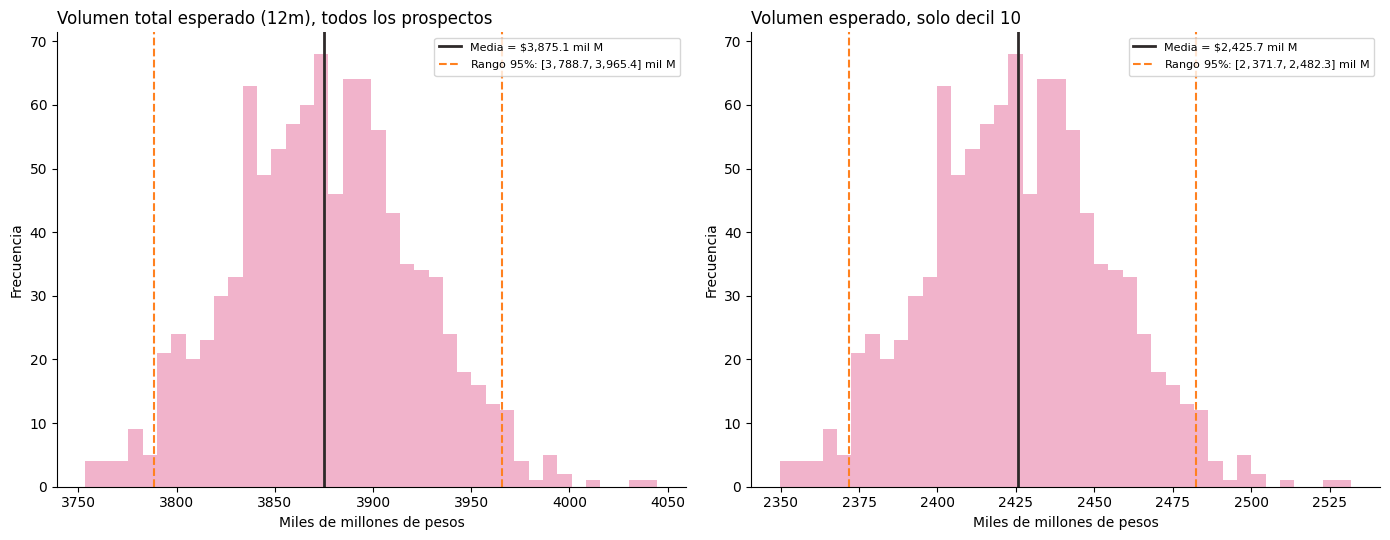

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

datos_bootstrap = [
    (volumen_total_boot, ci_total, "Volumen total esperado (12m), todos los prospectos"),
    (volumen_top_decil_boot, ci_top, "Volumen esperado, solo decil 10"),
]

for ax, (dist, ci, titulo) in zip(axes, datos_bootstrap):
    ax.hist(dist / 1e9, bins=40, color=PALETA['rosa'], alpha=0.85)
    ax.axvline(dist.mean() / 1e9, color=ATENUADO, linewidth=2, label=f"Media = ${dist.mean()/1e9:,.1f} mil M")
    ax.axvline(ci[0] / 1e9, color=ALERTA, linestyle="--", label=f"Rango 95%: [${ci[0]/1e9:,.1f}, ${ci[1]/1e9:,.1f}] mil M")
    ax.axvline(ci[1] / 1e9, color=ALERTA, linestyle="--")
    ax.set_xlabel("Miles de millones de pesos")
    ax.set_ylabel("Frecuencia")
    ax.set_title(titulo, fontsize=12, loc="left")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Estas dos gráficas muestran los resultados de una simulación que estima el volumen de negocio esperado en los próximos 12 meses, comparando el total de todos los prospectos frente a únicamente los del decil 10, es decir, el grupo con mayor potencial. En el panel izquierdo, el volumen esperado para toda la base se ubica alrededor de 3,875 mil millones de pesos, con un rango de confianza del 95% relativamente angosto, entre 3,789 y 3,965 mil millones. Esto indica que, aunque existen variaciones entre los distintos escenarios simulados, el resultado es bastante estable y predecible.

En el panel derecho se aísla solo el decil 10, el segmento de clientes más prometedores, y se observa que este grupo por sí solo aporta cerca de 2,426 mil millones de pesos, lo que representa una proporción muy significativa del volumen total esperado, cercana al 63%. Esto confirma que una parte relativamente pequeña de los prospectos concentra la mayor parte del potencial de negocio, por lo que enfocar los esfuerzos comerciales en este grupo podría ser especialmente rentable. La forma similar de ambas distribuciones sugiere además que el comportamiento del decil 10 es el que principalmente determina el resultado total.

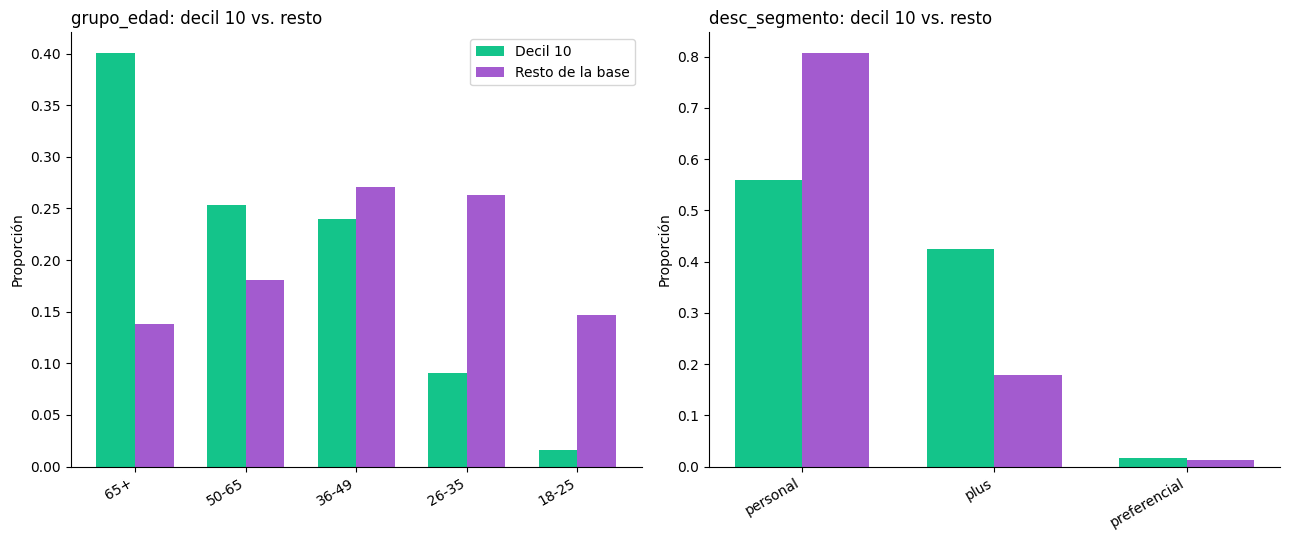

In [66]:
prospectos_decil = df_abt_crean[df_abt_crean["decil_priorizacion"].notna()].copy()
decil_top = prospectos_decil[prospectos_decil["decil_priorizacion"] == 10]
resto = prospectos_decil[prospectos_decil["decil_priorizacion"] != 10]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, col in zip(axes, ["grupo_edad", "desc_segmento"]):
    tabla = pd.concat([
        decil_top[col].value_counts(normalize=True).rename("Decil 10"),
        resto[col].value_counts(normalize=True).rename("Resto de la base"),
    ], axis=1).fillna(0)
    tabla = tabla.reindex(tabla["Decil 10"].sort_values(ascending=False).index)
    x = np.arange(len(tabla))
    ancho = 0.35
    ax.bar(x - ancho/2, tabla["Decil 10"], width=ancho, label="Decil 10", color=PRINCIPAL)
    ax.bar(x + ancho/2, tabla["Resto de la base"], width=ancho, label="Resto de la base", color=PALETA['violeta'])
    ax.set_xticks(x); ax.set_xticklabels(tabla.index, rotation=30, ha="right")
    ax.set_ylabel("Proporción")
    ax.set_title(f"{col}: decil 10 vs. resto", fontsize=12, loc="left")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend()
plt.tight_layout()
plt.show()

Estas gráficas describen el perfil de los clientes que conforman el decil 10, el grupo de mayor potencial identificado en el análisis anterior, comparándolo con el resto de la base. En cuanto a la edad, se observa una diferencia clara: el decil 10 está compuesto en mayor proporción por personas de 65 años o más, mientras que en el resto de la base predominan los grupos de edades intermedias y jóvenes. Esto sugiere que el potencial de negocio identificado está fuertemente asociado a clientes de mayor edad, posiblemente porque han tenido más tiempo para acumular patrimonio o ingresos.

En cuanto al segmento comercial, tanto el decil 10 como el resto de la base están concentrados mayormente en el segmento personal, aunque en proporciones distintas: en el resto de la base este segmento es abrumadoramente dominante, mientras que en el decil 10 el segmento plus tiene una participación bastante más alta que en el resto. El segmento preferencial es minoritario en ambos grupos. En conjunto, estas gráficas indican que los clientes con mayor potencial tienden a ser personas mayores y con un perfil comercial algo más elevado que el promedio de la base.

In [67]:
pct_65_top = (decil_top["grupo_edad"] == "65+").mean()
pct_65_resto = (resto["grupo_edad"] == "65+").mean()
print(f"Clientes 65+ -- decil 10: {pct_65_top:.1%} | resto de la base: {pct_65_resto:.1%}")


Clientes 65+ -- decil 10: 40.1% | resto de la base: 13.8%


El decil 10 está claramente inclinado hacia clientes mayores: el 40.1% de sus clientes tiene 65 años o más, frente a solo 13.8% en el resto de la base — casi el triple de representación. Los grupos de edad intermedia y joven (18-35 años), en cambio, están subrepresentados en el decil 10 frente a su peso en el resto de la base. El potencial de negocio identificado está, entonces, fuertemente asociado a clientes de mayor edad.

**Nota de idoneidad:** el modelo de monto identifica la edad (65 anios o mas) como una variable con peso propio (ver importancia de variables), y el decil 10 termina sobrerrepresentando a este grupo frente al resto de la base. Antes de usar este ranking para dirigir campanias comerciales de productos de inversion, conviene que el area de cumplimiento revise si aplica algun criterio de idoneidad o proteccion al cliente de edad avanzada -- el modelo prioriza por potencial financiero, no evalua si ese producto es adecuado para el perfil de riesgo de cada cliente.


## Persistencia del modelo y exportación

In [68]:
import joblib
RUTA_MODELO_MONTO = "/content/drive/MyDrive/data/modelo_monto_potencial.joblib"
joblib.dump(modelo_monto_produccion, RUTA_MODELO_MONTO)
print(f"Modelo persistido en {RUTA_MODELO_MONTO}")

Modelo persistido en /content/drive/MyDrive/data/modelo_monto_potencial.joblib


# Supuestos y conclusiones

## Resumen de supuestos

Este modelo se entrena únicamente sobre los clientes que ya tienen CDT, inversión virtual o invesbot (87,032 clientes, el 10.12% de la base). CDT se incluye aquí aunque en el modelo de propensión no cuente como adopción digital, porque son dos preguntas distintas: una mide si el cliente va a adoptar la nueva app, y esta mide cuánto invertiría dado su perfil financiero — y quien ya tiene un CDT demuestra una capacidad e intención real de invertir, sin importar el canal.

Para saber cuánto invierte cada cliente se usan dos criterios, según qué tan segura sea la fecha en la que empezó a invertir. Cuando esa fecha es confiable, se mide su comportamiento en los primeros seis meses reales desde que adoptó — no doce, porque los datos disponibles apenas cubren unos trece meses y no dan para sostener una ventana más larga. Cuando la fecha no se puede confirmar, porque el cliente ya invertía desde antes de que empezara a recolectarse la información, se usa su historial completo como la mejor aproximación disponible. Esta ventana de seis meses se comprobó producto por producto, no se asumió igual para los tres: en CDT el saldo prácticamente no se mueve después de la adopción, así que no hay sesgo; en inversión virtual tampoco crece en promedio, aunque una parte real de los clientes retira dinero; y en invesbot el saldo sigue subiendo con claridad después del sexto mes, así que ahí la estimación probablemente se queda corta frente al potencial real a doce meses.

Las variables que alimentan el modelo nunca incluyen el saldo ni la tenencia de CDT, inversión virtual o invesbot, precisamente porque el modelo se va a aplicar a clientes que no tienen ninguno de esos productos. En su lugar se usa la capacidad financiera del cliente (ingresos, patrimonio, deudas), su comportamiento con otros productos del banco (ahorro, cuenta corriente, bolsillos, fiducuenta, sobregiros) y su perfil demográfico (edad, género, segmento, tipo de vivienda, nivel de ingreso). Esto último se incluye bajo un argumento de parecido: como no hay forma de observar comportamiento inversionista en alguien que nunca ha invertido, se aprovecha qué tan similar es a quienes sí lo hacen.

Entre las alternativas de modelo probadas, se eligió una que estima directamente el promedio esperado de inversión, en vez de una que estima primero en una escala transformada y luego intenta corregir el resultado hacia atrás. La razón es práctica: el objetivo final es sumar el potencial de miles de clientes para dimensionar la oportunidad total, y esa suma solo es confiable si cada estimación individual corresponde a un promedio, no a un valor típico o mediano. En la práctica, este modelo también calibró mejor que la alternativa, sobre todo en el grupo de clientes con mayor potencial, que es justo el que más pesa en la cifra final.

También se ponderó cada cliente según qué tan sólido es el dato detrás de su historial —un cliente con una sola observación pesa menos que uno con historia consolidada—, aunque al comprobarlo no cambió mayor cosa el resultado; se mantiene de todas formas por buena práctica. El modelo final se reentrenó sobre el cien por ciento de los inversionistas disponibles, no solo sobre la porción usada para probarlo. Y se construyó un puntaje de qué tan parecido es cada cliente de la base completa a un inversionista real, que confirmó que ningún cliente se parece demasiado a uno —el más parecido apenas alcanza la mitad de una escala completa—, lo que deja claro que toda estimación de monto para quien no invierte es una aproximación razonada, nunca una certeza.

el modelo de propensión se entrena con class_weight="balanced" para compensar que solo ~2.5% de la base adopta hoy. Ese ajuste mejora la capacidad de ordenar a los clientes, pero como efecto secundario las probabilidades que entrega dejan de estar calibradas al valor real: son un score relativo para priorizar, no una probabilidad literal de conversión. Un decil con probabilidad promedio de 0.64, por ejemplo, no significa que el 64% de esos clientes vaya a adoptar — significa que, dentro de la base, son los que el modelo considera comparativamente más propensos. El uso correcto es ordenar por decil, nunca leer el número de probabilidad como una cifra de conversión esperada.

Por último, el valor esperado de cada cliente se calcula multiplicando la probabilidad de que adopte por el monto que se estima que invertiría. Esto asume que ambas señales son relativamente independientes entre sí, algo que se comprobó y resultó cierto solo de forma parcial: hay una relación débil entre una y otra, no nula. A los clientes que ya adoptaron se les asigna probabilidad de uno por convención, y quedan fuera del ranking de priorización, porque no tendría sentido dirigirles una campaña de algo que ya tienen. La decisión de dividir el target según la fecha de adopción se deja tal como está, sin más pruebas adicionales sobre esa ventana de seis meses: el historial disponible es demasiado corto para sostener una validación más profunda por ahora. Y, a diferencia del modelo de propensión, que excluye a propósito las variables demográficas para no depender de a qué grupo pertenece el cliente, este modelo sí las usa —una decisión consciente, que trae de vuelta ese tipo de sesgo justo en la etapa final del proceso.


## Conclusiones

El modelo explica cerca de una cuarta parte de las diferencias en cuánto invierte cada cliente, un resultado modesto si se busca precisión individual, pero mucho más útil si lo que importa es el orden: al comprobar qué tan bien distingue entre quien invertiría más y quien invertiría menos, el resultado mejora de forma notoria. En otras palabras, el modelo no acierta el monto exacto de cada persona, pero sí es confiable para agrupar y priorizar, que es justamente el uso que se le va a dar.

La forma elegida de estimar el monto superó a la alternativa considerada tanto en sustento teórico como en resultados prácticos: en el grupo de clientes con mayor potencial —el que más pesa en la cifra final de negocio— este modelo se quedó corto por apenas un 8%, mientras que la alternativa se pasó por casi un 19%.

El patrimonio total del cliente es, con diferencia, lo que más influye en cuánto invertiría —muy por encima de cualquier otra variable—, seguido del saldo de ahorro y del ingreso mensual. Con menor peso aparecen el saldo en fiducuenta y bolsillos, el ingreso estimado por el banco, y pertenecer al grupo de 65 años o más.

Al combinar este modelo con el de propensión, la oportunidad de negocio proyectada a doce meses ronda los \$3.88 billones de pesos, de los cuales cerca del 63% —unos \$2.43 billones— se concentra en el 10% de clientes con mayor potencial, un grupo de casi 80,000 personas. Ese grupo prioritario tiene un perfil demográfico marcado: cuatro de cada diez de sus clientes tiene 65 años o más, frente a poco más de uno de cada diez en el resto de la base, y tiene mayor presencia del segmento plus (42% frente a 18% en el resto de la base), mientras que el segmento preferencial se mantiene igual de presente en ambos grupos. Este patrón no fue buscado a propósito por el modelo, pero terminó apareciendo de todas formas, por la vía del parecido demográfico con los inversionistas actuales.

Durante la revisión de este notebook se corrigieron varios problemas técnicos: el orden en que estaban guardadas las celdas no permitía correr el análisis de principio a fin sin errores; el chequeo de independencia entre probabilidad y monto estaba mezclando datos que no debían entrar ahí; una variable redundante seguía usándose pese a que el propio análisis ya la había descartado; y el rango de incertidumbre de la cifra de negocio transmitía más seguridad de la que realmente tiene, así que se dejó documentado con claridad que ese rango es un piso, no el techo, de la incertidumbre real.


# Cierre pipeline (bronze + silver)

## Visión general de todos los notebooks

El estudio completo avanza en capas, y cada una se apoya en la anterior. La primera capa integra siete fuentes de información en una sola base de casi 860 mil clientes, y ahí aparece el hallazgo que termina condicionando todo lo que sigue: el historial disponible es corto y disperso, y ningún cliente tiene un registro mensual completo. En vez de aparentar más certeza de la que hay, esta capa construye cada indicador junto con una señal de qué tan confiable es, para que el resto del estudio herede esa honestidad en lugar de esconderla.

La segunda capa agrupa a los clientes según su comportamiento financiero y confirma, con evidencia directa, dónde está la oportunidad de negocio: el 71% de la base tiene poco o ningún producto con el banco. La oportunidad más grande no está en venderle más a quien ya invierte, está en activar a esa mayoría que hoy prácticamente no usa el banco. También queda claro que quien ya invierte lo hace casi siempre en un solo producto, lo que abre una oportunidad distinta de venta cruzada dentro de la base que ya está activa.

La tercera capa construye el modelo que predice quién es más probable que adopte la nueva aplicación de inversión. A propósito, no toma en cuenta la edad ni el género del cliente, para que la priorización comercial no dependa de a qué grupo pertenece. El hallazgo principal es que lo que más predice la adopción no es cuánta plata tiene el cliente, sino qué tan activa es su relación con el banco: quien ya usa ahorro, bolsillos o fiducuenta de forma organizada es quien más probablemente da el siguiente paso. Aun así, el grupo que el modelo termina priorizando resulta tener más presencia de clientes mayores y de segmento plus, no porque el modelo lo haya buscado, sino porque ese comportamiento activo está naturalmente asociado a ese perfil.

La cuarta capa, la de este notebook, estima cuánto invertiría cada cliente si llegara a adoptar. A diferencia de la anterior, sí usa la edad, el género y el segmento como parte de la estimación, porque para alguien que nunca ha invertido no existe otra forma de aproximar su comportamiento que no sea por parecido con quienes sí invierten. Al multiplicar la probabilidad de adopción por el monto estimado se llega a la cifra final de oportunidad de negocio, y ahí se confirma —ahora sí de forma directa y medible— que el grupo prioritario está claramente inclinado hacia clientes mayores y de segmento plus.

La conclusión más importante de todo el estudio está justo en ese cruce: el modelo que decide quién es un buen prospecto evita a propósito depender de la edad o el segmento del cliente, pero el modelo que decide cuánto vale ese prospecto sí depende de esas variables. El resultado final que termina viendo el negocio no hereda, entonces, la neutralidad que uno de los dos modelos sí logró por su cuenta.

## Limitaciones del estudio

La limitación de fondo, que atraviesa las cuatro capas, es que el historial disponible apenas cubre poco más de un año, y ningún cliente tiene un registro mensual completo. Esto impide estudiar tendencias reales, obliga a trabajar con ventanas cortas y criterios aproximados en vez de mediciones exactas, y no permite comprobar si los modelos se sostienen igual de bien con datos de un año distinto al que se usó para construirlos.

Los dos modelos de aprendizaje automático dependen de definiciones razonables pero no del todo verificables, por la misma razón: qué cuenta como adopción digital, o qué ventana de tiempo representa mejor el comportamiento de inversión de un cliente reciente. Además, el modelo de monto se entrena solo con quienes ya invierten y se aplica al resto de la base por parecido, sabiendo que ningún cliente de esa base se parece demasiado a un inversionista real —apenas alcanza la mitad de una escala de similitud completa—, así que toda estimación para quien no invierte es una extrapolación, no una medición directa. Algunos de los grupos usados para construir ese modelo, en particular los adoptantes recientes de CDT e invesbot, son además bastante pequeños, así que sus estimaciones son las menos firmes de los tres productos.

Como ya se mencionó, el estudio tampoco es neutral frente a variables demográficas de punta a punta: aunque el modelo de propensión evita depender de la edad o el segmento, el modelo de monto sí las usa, y el resultado combinado termina reflejando ese sesgo en la etapa final. El rango de incertidumbre calculado para la cifra total de negocio, además, solo refleja una parte del error posible —el propio del modelo de monto—, sin incluir la incertidumbre del modelo de propensión ni el riesgo de estar extrapolando hacia clientes que no se parecen a un inversionista típico, así que el margen de error real es más amplio que el reportado.

Por último, uno de los grupos identificados en la segunda capa (apenas el 1.3% de la base) no representa un comportamiento real de cliente, sino una falta casi total de información financiera declarada. Cualquier conclusión que lo trate como un perfil genuino, en vez de un vacío de dato, estaría mal fundamentada.


## Recomendaciones técnicas futuras

Lo primero, en cuanto se acumule más historia —idealmente el doble de la que hay hoy—, es revisar si las ventanas de tiempo usadas para construir los dos modelos siguen siendo las correctas, y aprovechar esa historia adicional para comprobar si los modelos predicen igual de bien en un período que no se usó para entrenarlos, algo que hoy no es posible hacer.

También conviene establecer una rutina de seguimiento para ambos modelos, repitiendo las mismas pruebas de estabilidad y calibración cada vez que se reentrenen con datos nuevos, para detectar a tiempo si el comportamiento de los clientes empieza a cambiar. La tensión entre los dos modelos frente a las variables demográficas debería resolverse de forma explícita y no dejarse como una diferencia de diseño no discutida: vale la pena decidir, a nivel de negocio, si todo el proceso debe ser neutral frente a edad y segmento, y si es así, medir cuánto costaría en desempeño quitar esas variables del modelo de monto.

Sería valioso, además, incorporar la incertidumbre del modelo de propensión al cálculo del rango de negocio, en vez de que ese rango refleje solamente la incertidumbre del modelo de monto. El grupo de clientes sin información financiera real, identificado en la segunda capa, merece un tratamiento aparte antes de usarse en cualquier modelo futuro, posiblemente enriqueciendo esos registros con otras fuentes de ingreso. Y las validaciones que en este estudio se hicieron de forma manual —revisar que el análisis corra de principio a fin sin errores, comprobar la independencia entre probabilidad y monto, verificar la calibración por grupo de clientes— convendría automatizarlas, de cara a que este proceso se repita de forma periódica.

## Recomendaciones para el negocio

La prioridad comercial más clara es activar a la mayoría de clientes que hoy prácticamente no usa ningún producto con el banco —siete de cada diez—, antes que enfocar esfuerzos en venderle más a quien ya invierte. Dentro de esa base ya activa, además, existe una oportunidad de venta cruzada real, porque quien ya invierte casi siempre lo hace en un solo producto.

El esfuerzo comercial rinde mucho más si se concentra en el grupo de clientes con mayor puntaje, en vez de repartirse por igual en toda la base: tanto en el modelo de quién adopta como en el de cuánto invertiría, la mayor parte de la oportunidad real está concentrada en una porción pequeña de clientes. Una campaña general, sin ese enfoque, diluye el esfuerzo justo donde menos rinde.

El mejor candidato para una campaña no es necesariamente el cliente con más plata, sino el que ya tiene una relación activa y organizada con el banco —quien usa ahorro, bolsillos o fiducuenta de forma consistente—. Antes de dirigir campañas al grupo de mayor potencial de inversión, sin embargo, conviene que el área de cumplimiento revise el criterio, porque ese grupo tiene una presencia notablemente alta de clientes de edad avanzada, y ese tipo de campañas suele requerir una validación adicional de que el producto ofrecido sea adecuado para ese perfil.

A los clientes que ya adoptaron la app conviene tratarlos como una oportunidad de consolidación o migración, no como un prospecto nuevo, y ya quedan correctamente excluidos del ranking de priorización. Finalmente, las cifras de oportunidad de negocio calculadas en este estudio —cerca de \$3.88 billones en total, con \$2.43 billones concentrados en el grupo prioritario— deben leerse como un orden de magnitud útil para planear, no como una cifra exacta de presupuesto, dado que el margen de error real es más amplio de lo que el rango reportado sugiere.